## # Exp. 4 | **ARIMA**
### GEC0319 | JIVB | Time Series
- Experiment N° **4**  
- Link: [here](https://ocw.mit.edu/courses/18-s096-topics-in-mathematics-with-applications-in-finance-fall-2013/1926c83ecd7ea700f7cb63914c6d7c0f_MIT18_S096F13_lecnote8.pdf)

### Settings

In [ ]:
import pandas as pd
import numpy as np
np.random.seed(42)
from random import random, gauss
from pandas.plotting import autocorrelation_plot
import warnings
import itertools

import requests
from io import StringIO
from string import ascii_letters



import statsmodels.formula.api as smf
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AR
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import seaborn as sns
import matplotlib.pyplot as plt



# general settings
class CFG:
    data_folder = '/data/'
    img_dim1 = 25
    img_dim2 = 8
    style = 'https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pitayasmoothie-light.mplstyle'


# adjust the parameters for displayed figures
plt.rcParams.update({'figure.figsize': (CFG.img_dim1,CFG.img_dim2)})
plt.style.use(CFG.style)


In [ ]:
# FUNCIONES

def sdt_get(serie, **kwargs):
    '''
    Fetches data from the "apis.datos.gob.ar" API.

    Parameters:
    serie: str or list of series IDs to query.
    kwargs: Additional parameters to refine the query:
              - start_date/end_date
              - collapse: week / month / quarter / year
              - collapse_aggregation: min / max / avg (default) / end_of_period
              - representation_mode: value (default) / change / change_a_year_ago / change_since_beginning_of_year / percent_change / percent_change_a_year_ago / percent_change_since_beginning_of_year

    Returns:
    DataFrame: The output is a pandas DataFrame with the 'indice_tiempo' as the index.
    '''

    # If serie is a list, convert it to a comma-separated string
    if isinstance(serie, list):
        serie = ','.join(serie)

    # Create the settings string from the kwargs
    settings = '&'.join([f"{k}={v}" for k, v in kwargs.items()])

    # Construct the final URL
    url = f"https://apis.datos.gob.ar/series/api/series/?format=csv&last=5000&ids={serie}&{settings}"

    try:
        # Make the GET request to fetch the data
        response = requests.get(url)

        # Check if the request was successful (status code 200)
        response.raise_for_status()

        # Read the response content as a CSV into a pandas DataFrame
        csv_data = StringIO(response.text)
        output = pd.read_csv(csv_data).set_index('indice_tiempo')

        # Convert the index to datetime format
        output.index = pd.to_datetime(output.index)
        return output

    except requests.exceptions.RequestException as e:
        # Handle HTTP or connection errors
        print(f"Error fetching data: {e}")
        return None

def sdt_compare(serie):
    '''
    compara los momentos de la distribución partinedo la serie en 2
    '''
    split =  int(len(serie) / 2)
    X1, X2 = serie[0:split], serie[split:]
    mean1, mean2 = np.round(X1.mean(),0), np.round(X2.mean(),0)
    std1, std2 = np.round(X1.std(),0), np.round(X2.std(),0)
    print(f'media A:{mean1} - media B:{mean2} - ratio A/B = {np.round(100*mean1/mean2,2)}%')
    print(f'desvest A : {std1} - desvest B: {std2}  - ratio A/B = {np.round(100*std1/std2,2)}%')
    return [mean1,mean2,std1,std2]

def sdt_auto_scatter(series,lags=9,ncols=3):
    '''
    gráfico de scatterplot para los rezagos
    '''
    series = pd.Series(series)

    nrows=int(np.ceil(lags/ncols))
    fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(4*ncols, 4*nrows))
    for ax, lag in zip(axes.flat, np.arange(1,lags+1, 1)):
        lag_str = 't-{}'.format(lag)
        X = (pd.concat([series, series.shift(-lag)], axis=1,
                       keys=['y'] + [lag_str]).dropna())

        X.plot(ax=ax, kind='scatter', y='y', x=lag_str);
        corr = X.corr().to_numpy()[0][1]# X.corr().as_matrix()[0][1]
        ax.set_ylabel('Original')
        ax.set_title('Lag: {} (corr={:.2f})'.format(lag_str, corr));
        ax.set_aspect('equal');
        sns.despine();
    fig.tight_layout();

def sdt_adf(serie):
  '''
  Test de Estacionariedad ADF
  '''
  result = adfuller(serie)
  print('ADF Statistic: %f' % result[0])
  print('p-value: %f' % result[1])
  print('Critical Values:')
  for key, value in result[4].items():
      print('\t%s: %.3f' % (key, value))
  return result


def sdt_sim(AR=[],I=0,MA=[],obs=1000,seed=113,title=''):
    '''
    simulador de procesos arima
    '''
    np.random.seed(seed)
    arparams = np.array(AR)
    maparams = np.array(MA)
    ar = np.r_[1, -arparams] # add zero-lag and negate
    ma = np.r_[1, maparams] # add zero-lag
    arma_process = sm.tsa.ArmaProcess(ar, ma)
    y = arma_process.generate_sample(1000)
    for i in range(I):
        y = y.cumsum()
    tsplot(pd.Series(y),title=title);
    return y

In [ ]:
import itertools


d_min = 0
q_min = 0
p_max = 4
d_max = 2
q_max = 4


def sdt_explore(series, p = [0,4],d=[0,2],q=[0,4]):
    # Initialize a DataFrame to store the results
    results_bic = pd.DataFrame(index=['AR{}'.format(i) for i in range(p[0],p[1]+1)],
                               columns=['MA{}'.format(i) for i in range(q[0],q[1]+1)])

    for i,j,k in itertools.product(range(p[0],p[1]+1),
                                   range(d[0],d[1]+1),
                                   range(q[0],q[1]+1)):
        if i==0 and j==0 and k==0:
            results_bic.loc['AR{}'.format(i), 'MA{}'.format(k)] = np.nan
            continue

        try:
            model = sm.tsa.SARIMAX(series, order=(i, j, k),
                                   #enforce_stationarity=False,
                                   #enforce_invertibility=False,
                                  )
            results = model.fit()
            results_bic.loc['AR{}'.format(i), 'MA{}'.format(k)] = results.bic
        except:
            continue
    results_bic = results_bic[results_bic.columns].astype(float)
    return results_bic

In [ ]:
import itertools

def sdt_explore(series, p = [0,4],d=[0,2],q=[0,4]):
    # Initialize a DataFrame to store the results
    results_bic = pd.DataFrame(index=['AR{}'.format(i) for i in range(p[0],p[1]+1)],
                               columns=['MA{}'.format(i) for i in range(q[0],q[1]+1)])
    results_aic = results_bic.copy()

    for i,j,k in itertools.product(range(p[0],p[1]+1),
                                   range(d[0],d[1]+1),
                                   range(q[0],q[1]+1)):
        if i==0 and j==0 and k==0:
            results_bic.loc['AR{}'.format(i), 'MA{}'.format(k)] = np.nan
            results_aic.loc['AR{}'.format(i), 'MA{}'.format(k)] = np.nan
            continue

        try:
            model = sm.tsa.SARIMAX(series, order=(i, j, k),
                                   #enforce_stationarity=False,
                                   #enforce_invertibility=False,
                                  )
            results = model.fit()
            results_bic.loc['AR{}'.format(i), 'MA{}'.format(k)] = results.bic
            results_aic.loc['AR{}'.format(i), 'MA{}'.format(k)] = results.aic
        except:
            continue
    results_bic = results_bic[results_bic.columns].astype(float)
    results_aic = results_aic[results_aic.columns].astype(float)
    return results_bic, results_aic

def get_min(df):
    return df.idxmin().loc[df.min().idxmin()], df.min().idxmin()

In [ ]:
# bic,aic = sdt_explore(_)

In [ ]:
aic.div(aic.mean().mean()).round(4)

,MA0,MA1,MA2,MA3,MA4
AR0,1.1618,0.9824,0.9804,0.9803,0.9805
AR1,1.0880,0.9807,0.9833,0.9810,0.9811
AR2,1.0555,0.9805,0.9812,0.9786,0.9809
AR3,1.0415,0.9809,0.9813,0.9811,0.9807
AR4,1.0325,0.9807,0.9815,0.9816,0.9819


In [ ]:
get_min(aic),get_min(bic)

(('AR2', 'MA3'), ('AR0', 'MA2'))

In [ ]:
# test = sdt_explore(_)

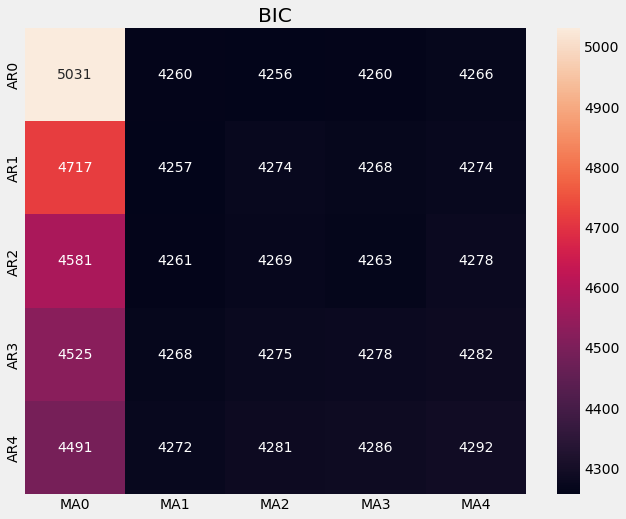

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
ax = sns.heatmap(test.astype(int),
                 mask=test.isnull(),
                 ax=ax,
                 annot=True,
                 fmt='.0f',
                 );
ax.set_title('BIC');

In [ ]:
test.astype(int)

,MA0,MA1,MA2,MA3,MA4
AR0,5031,4260,4256,4260,4266
AR1,4717,4257,4274,4268,4274
AR2,4581,4261,4269,4263,4278
AR3,4525,4268,4275,4278,4282
AR4,4491,4272,4281,4286,4292


In [ ]:
best_fit = test.idxmin().loc[test.min().idxmin()], test.min().idxmin()

('AR0', 'MA2')

# Descomposición

## Estimador Mensual de la Actividad Económica

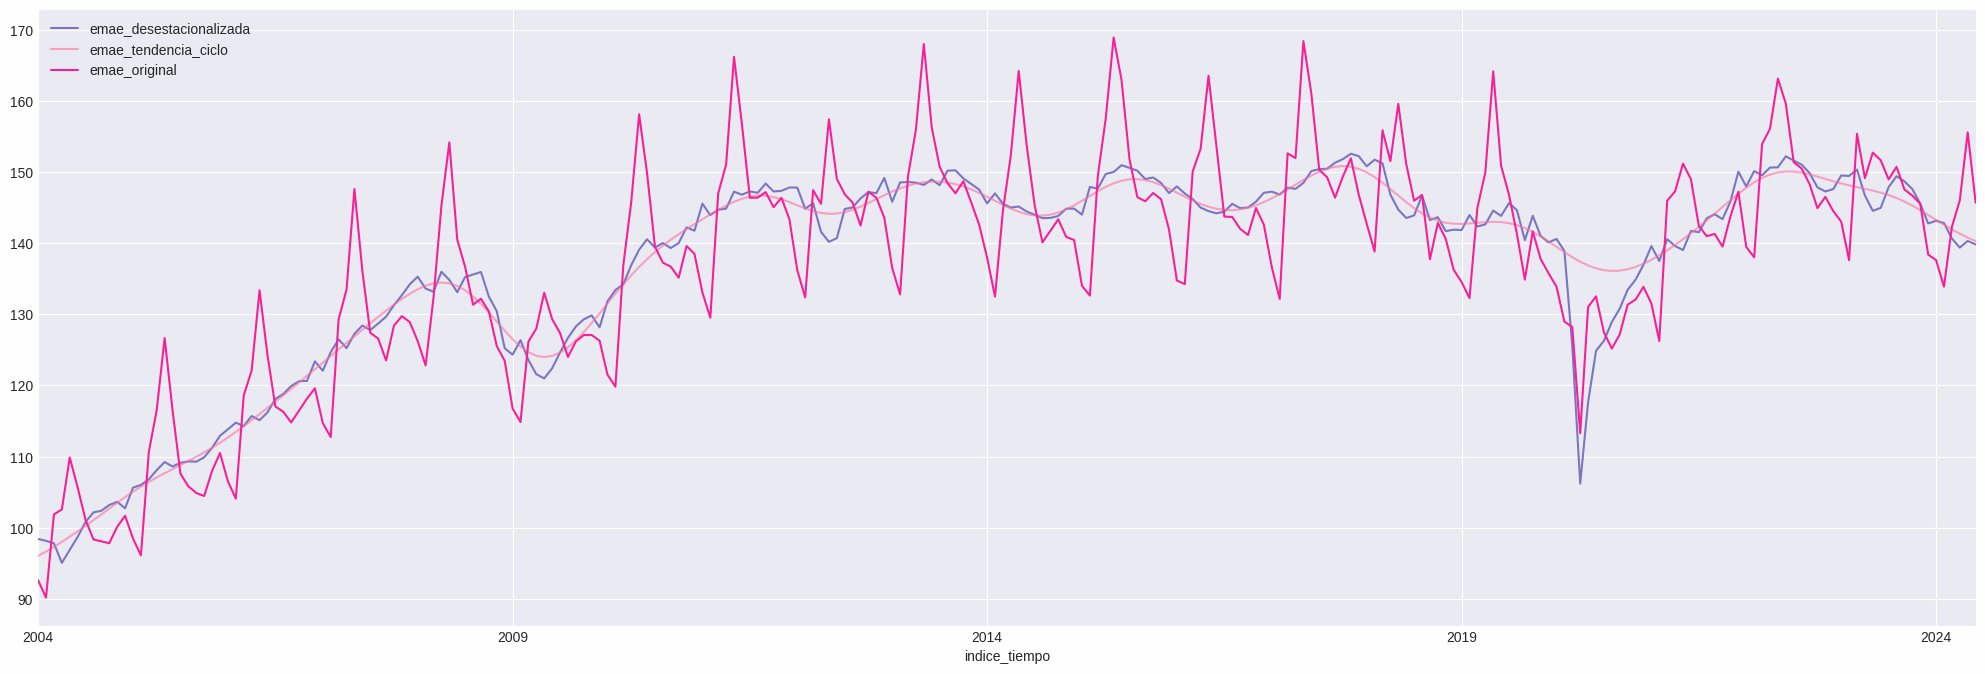

In [ ]:
df = sdt_get(['143.3_NO_PR_2004_A_31','143.3_NO_PR_2004_A_28','143.3_NO_PR_2004_A_21'])
df.head(2)
df.plot();

## Estudio por Sectores


In [ ]:
df = sdt_get('143.3_NO_PR_2004_A_21,11.3_VMATC_2004_M_12,11.3_VMASD_2004_M_23,11.3_VIPAA_2004_M_5,11.3_ISOM_2004_M_39,11.3_P_2004_M_20,11.3_AGCS_2004_M_41') #678arlyc

df.head(2)

,emae_original,construccion,industria_manufacturera,pesca,agricultura_ganaderia_caza_silvicultura,hoteles_restaurantes,comercio_mayorista_minorista_reparaciones
indice_tiempo,,,,,,,
2004-01-01,92.627506,95.938047,91.454610,42.547868,65.995350,108.411682,92.065338
2004-02-01,90.186179,98.853388,89.424852,62.440771,64.926598,103.448256,91.464718


In [ ]:
df.columns

Index(['emae_original', 'construccion', 'industria_manufacturera', 'pesca',
       'agricultura_ganaderia_caza_silvicultura', 'hoteles_restaurantes',
       'comercio_mayorista_minorista_reparaciones'],
      dtype='object')

In [ ]:
df_construccion = df[['construccion']]
df_construccion.tail()

,construccion
indice_tiempo,
2024-02-01,124.378919
2024-03-01,119.104152
2024-04-01,113.954730
2024-05-01,113.972290
2024-06-01,114.956863


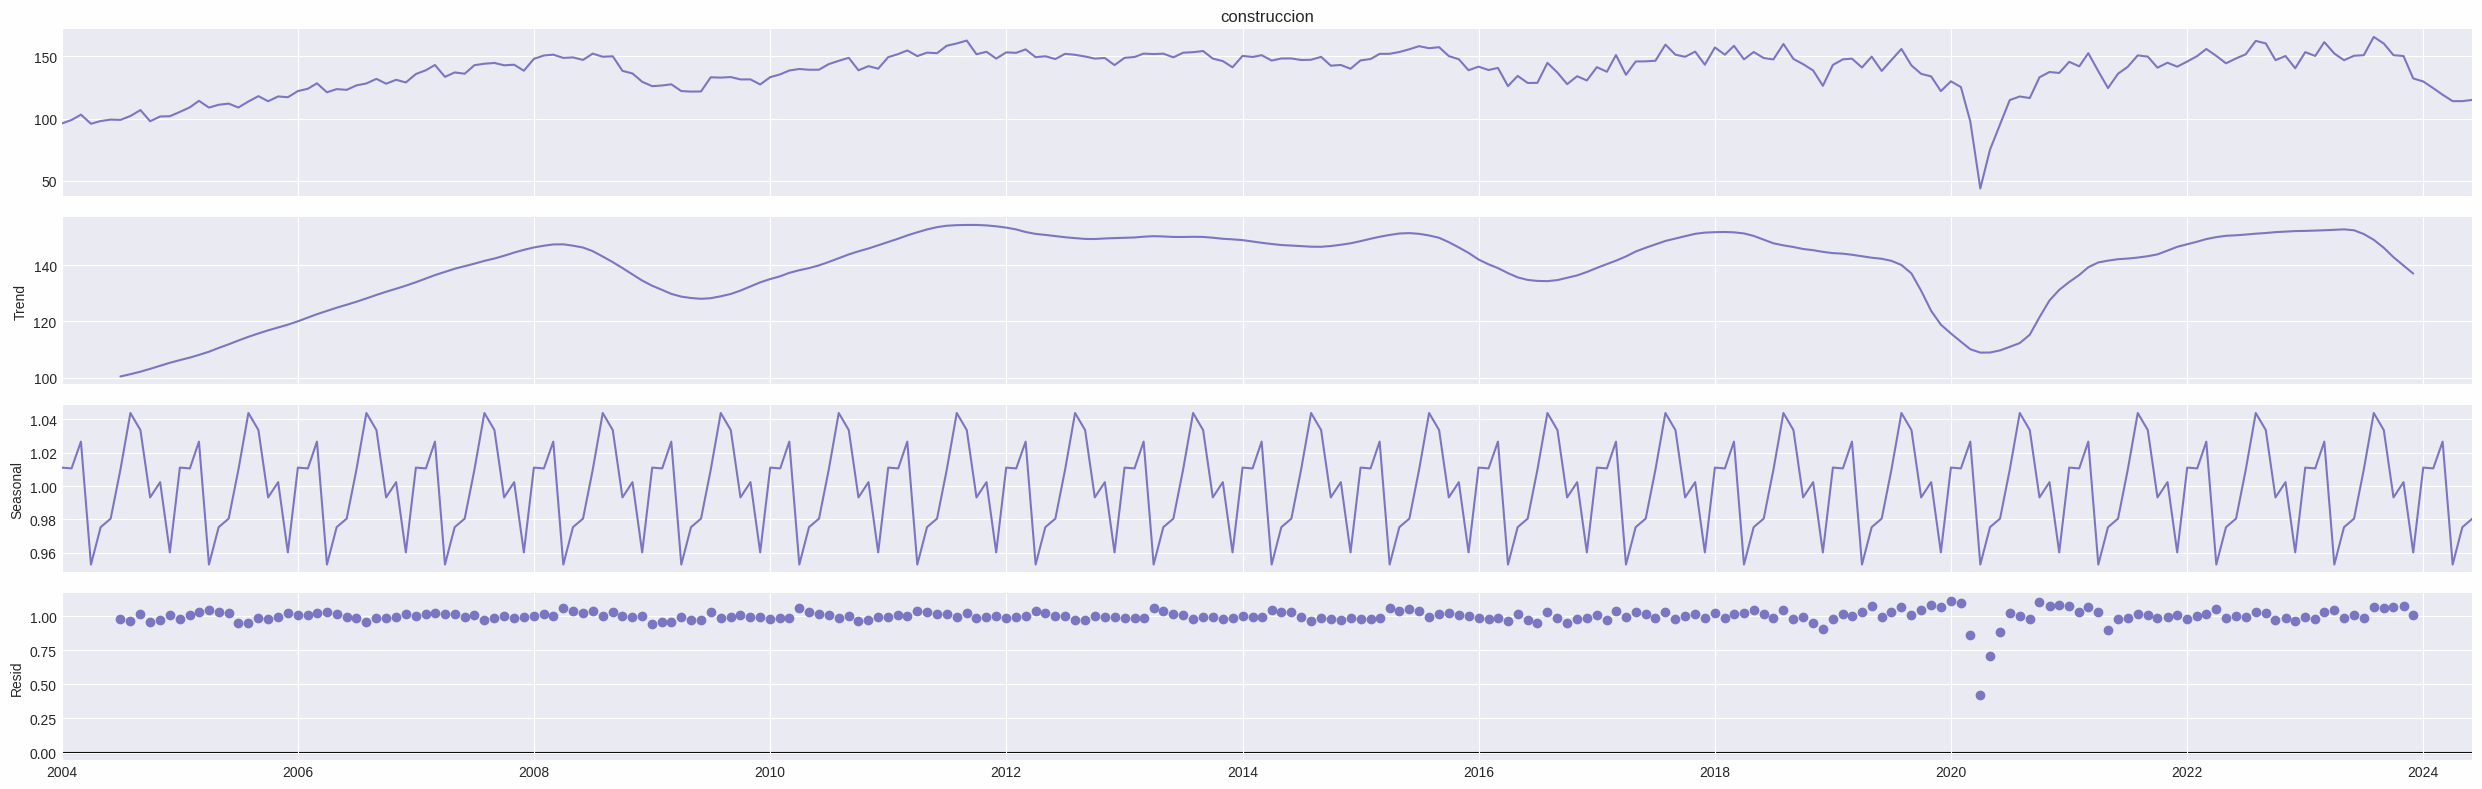

In [ ]:
decomposition = sm.tsa.seasonal_decompose(df_construccion["construccion"],period =12, model = 'multiplicative' )
figure = decomposition.plot()
plt.show()

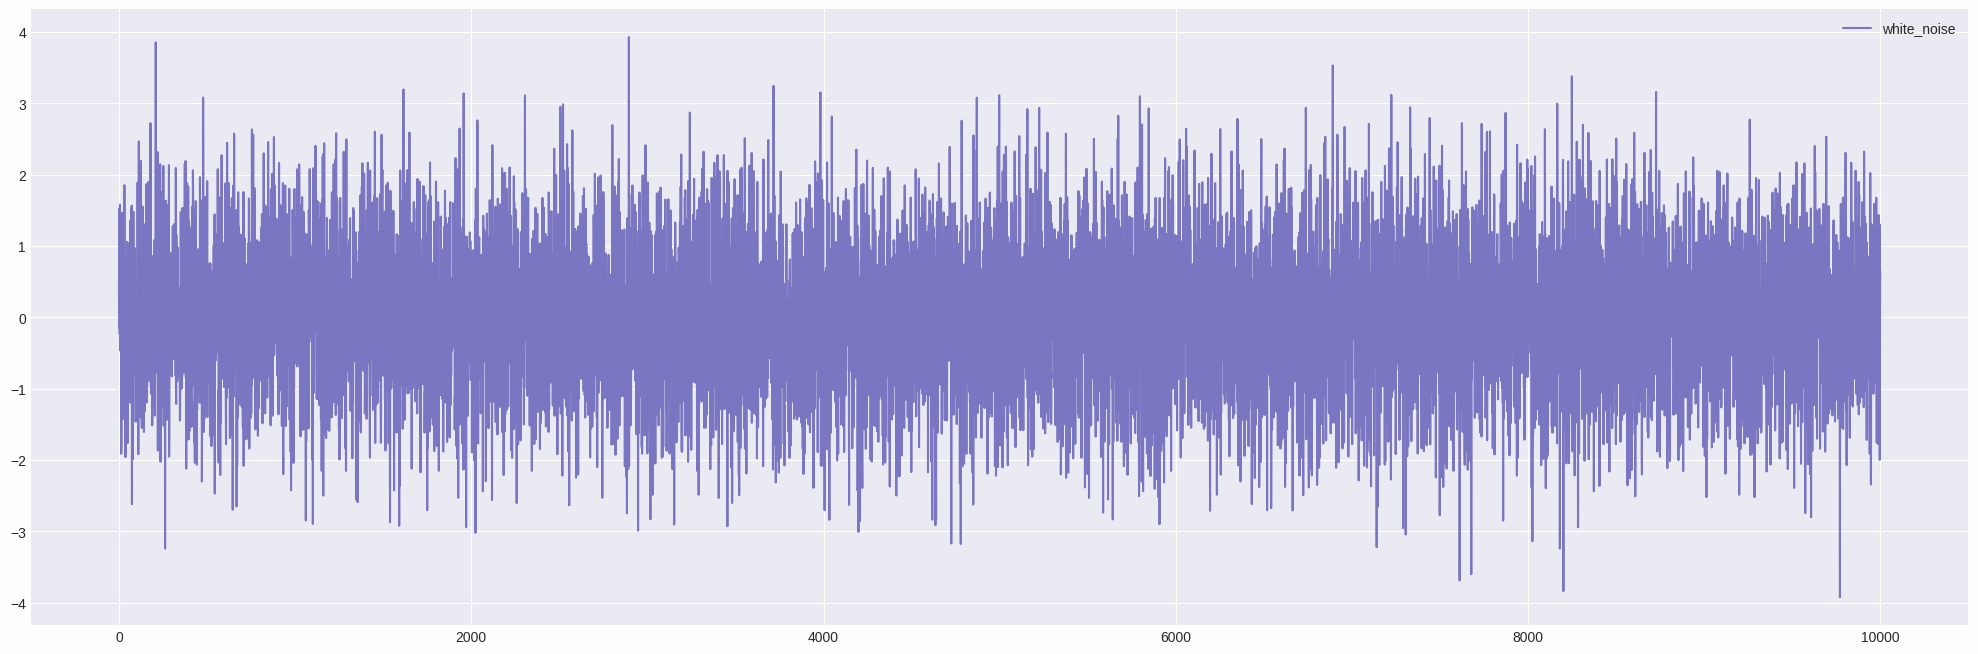

In [ ]:
xseries = pd.DataFrame(data = np.random.normal(0, 1, 10000), columns = ['white_noise'] )
xseries.plot()
print()

### SUBE

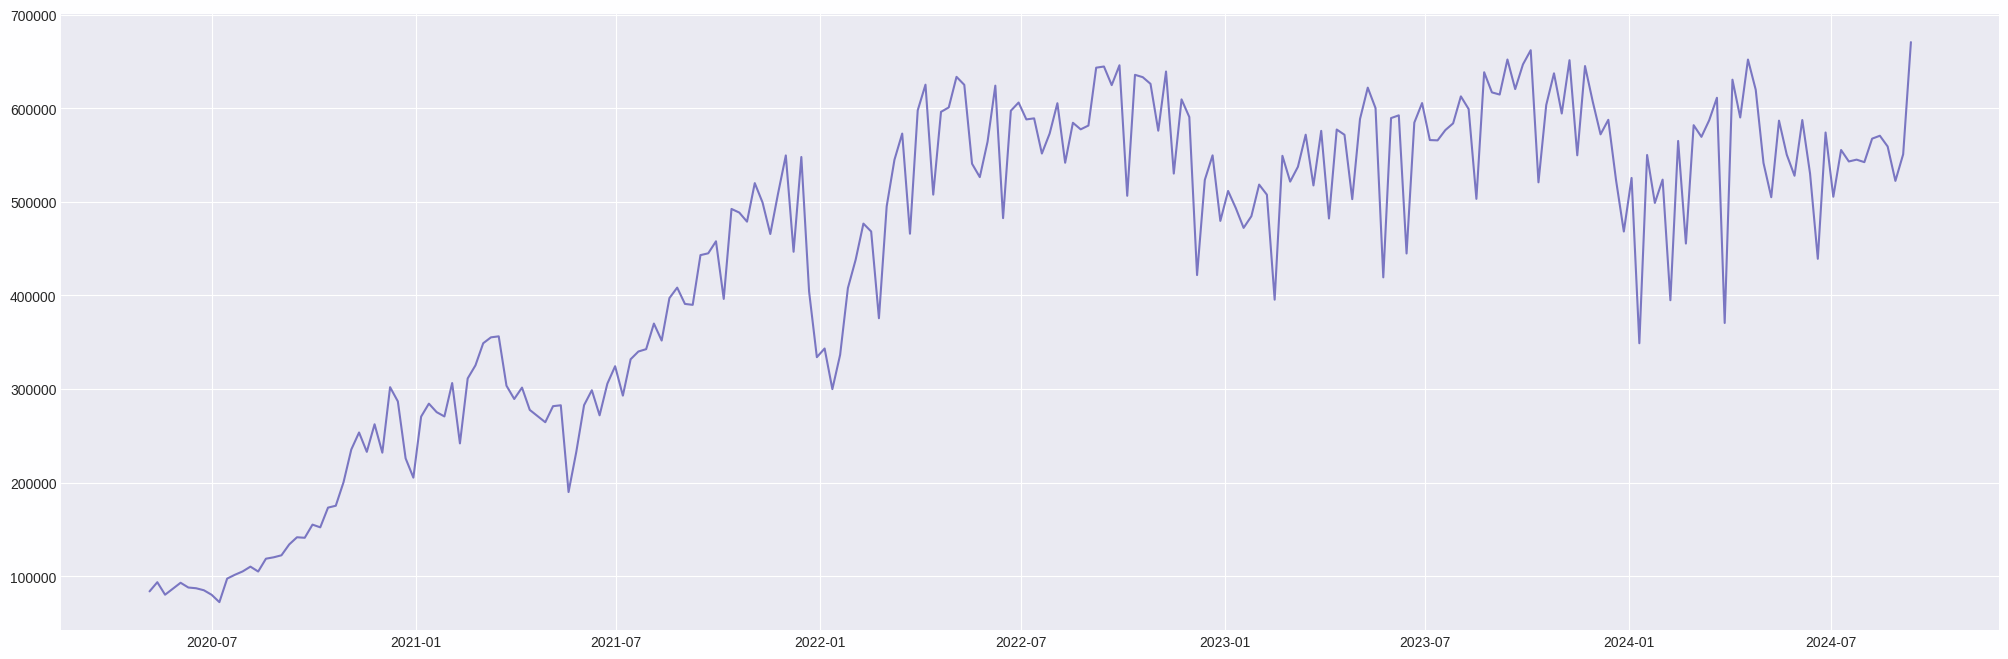

In [ ]:
df = sdt_get('678arlyc',collapse='week',start_date='2020-05')
plt.plot(df)

In [ ]:
decomposition = sm.tsa.seasonal_decompose(df["tren"],period =52, model = 'multiplicative' )
figure = decomposition.plot()
plt.show()

KeyError: 'tren'

Obtenemos los primeros momentos de la distribución:

In [ ]:
X = df.tren.values
split =  int(len(X) / 2)
X1, X2 = X[0:split], X[split:]
mean1, mean2 = np.round(X1.mean()/1000,0), np.round(X2.mean()/1000,0)
var1, var2 = np.round(X1.std()/1000,0), np.round(X2.std()/1000,0)
print('mean:')
print('chunk1: %.2f vs chunk2: %.2f' % (mean1, mean2))
print('variance:')
print('chunk1: %.2f vs chunk2: %.2f' % (var1, var2))


mean:
chunk1: 331.00 vs chunk2: 559.00
variance:
chunk1: 160.00 vs chunk2: 64.00


In [ ]:
_ = sdt_compare(df.tren.values)

media A:331452.0 - media B:559436.0 - ratio A/B = 59.25%
desvest A : 160308.0 - desvest B: 64387.0  - ratio A/B = 248.98%


## ADF: Test de Estacionariedad

In [ ]:
result = sdt_adf(X)

ADF Statistic: -2.078756
p-value: 0.253142
Critical Values:
	1%: -3.460
	5%: -2.875
	10%: -2.574


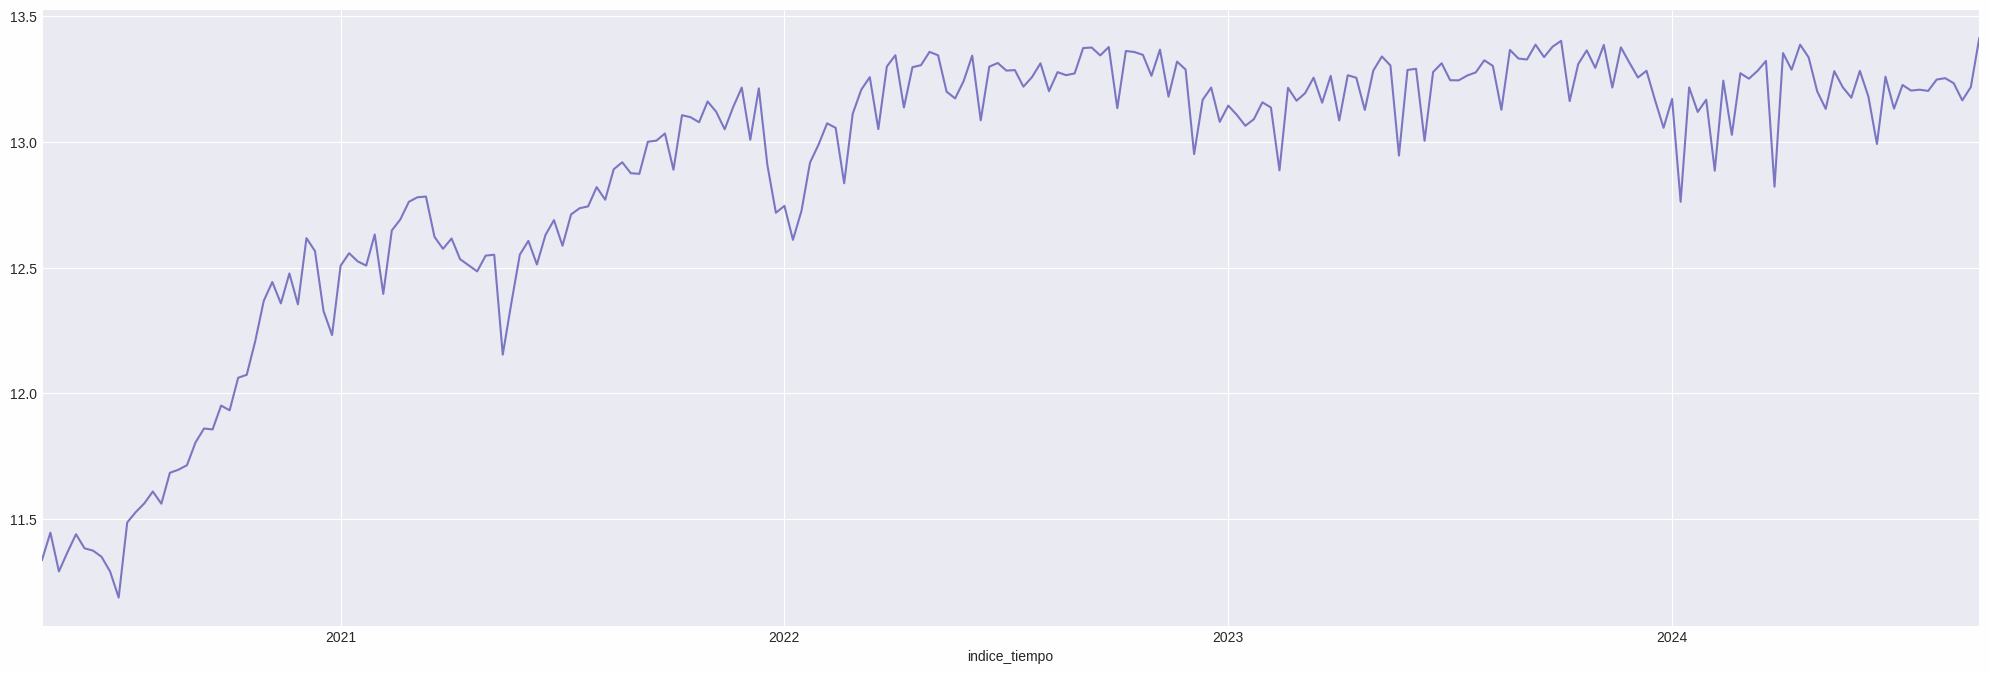

In [ ]:
df['tren2'] = np.log(df['tren'])
df.tren2.plot()
plt.show()

La transformación logarítmica nos acerca al rechazo

In [ ]:
result = sdt_adf(df.tren2)

ADF Statistic: -3.244899
p-value: 0.017528
Critical Values:
	1%: -3.460
	5%: -2.875
	10%: -2.574


Si a la transformación logarítmica le aplicamos una diferencia:

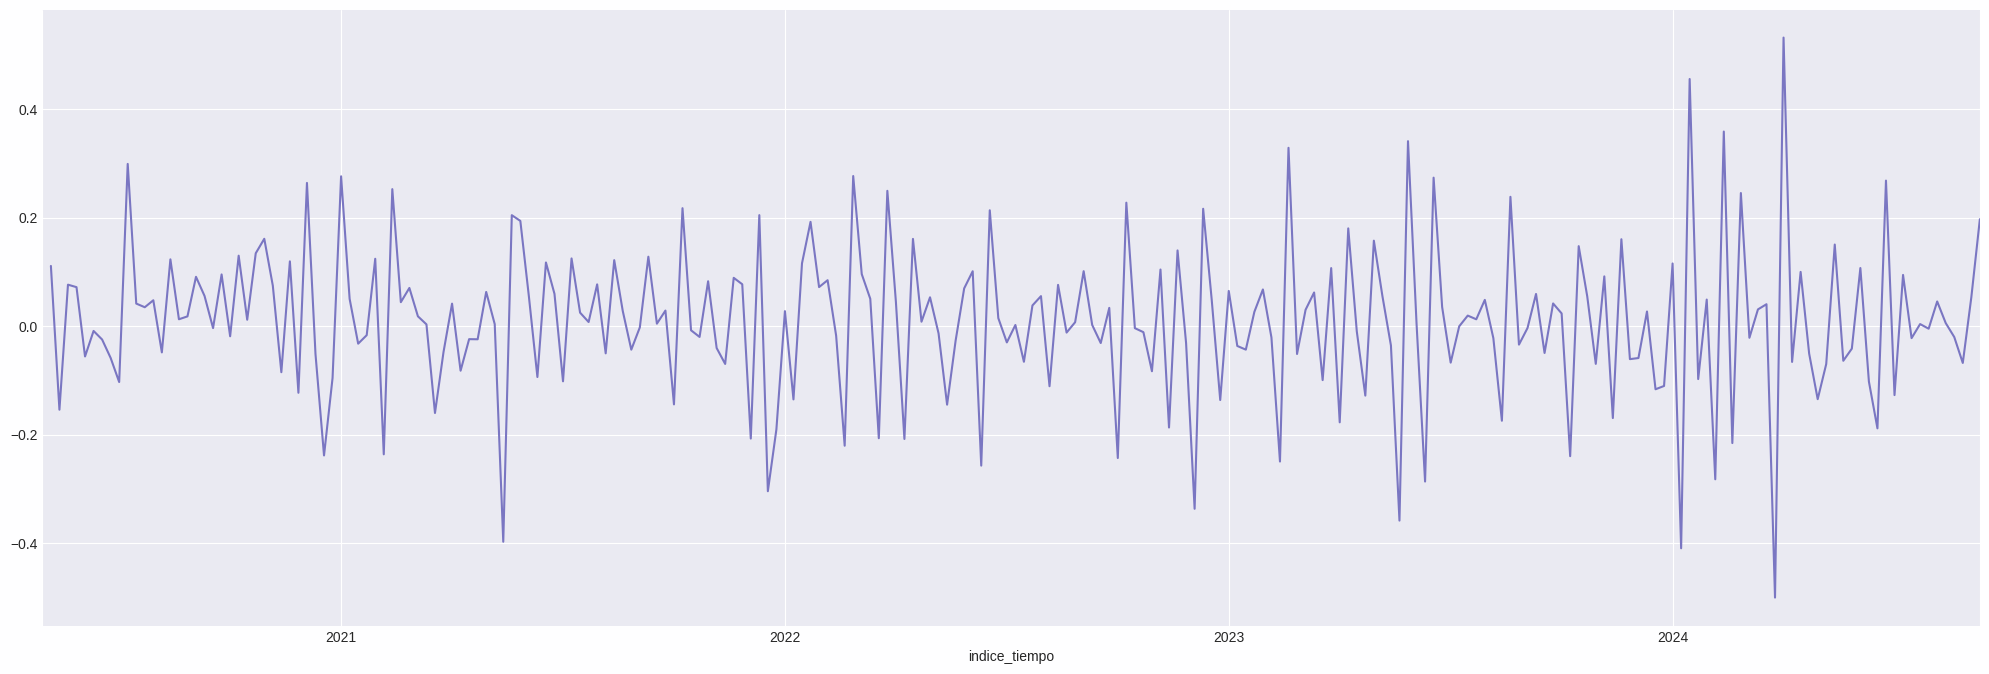

In [ ]:
df['diff_tren2'] = df['tren2'].diff()
df.diff_tren2.plot()
plt.show()

Así, obtenemos un rechazo claro:

In [ ]:
result = sdt_adf(df.diff_tren2[1:])

ADF Statistic: -16.543328
p-value: 0.000000
Critical Values:
	1%: -3.460
	5%: -2.874
	10%: -2.574


Integrando las transformaciones en una línea de código:

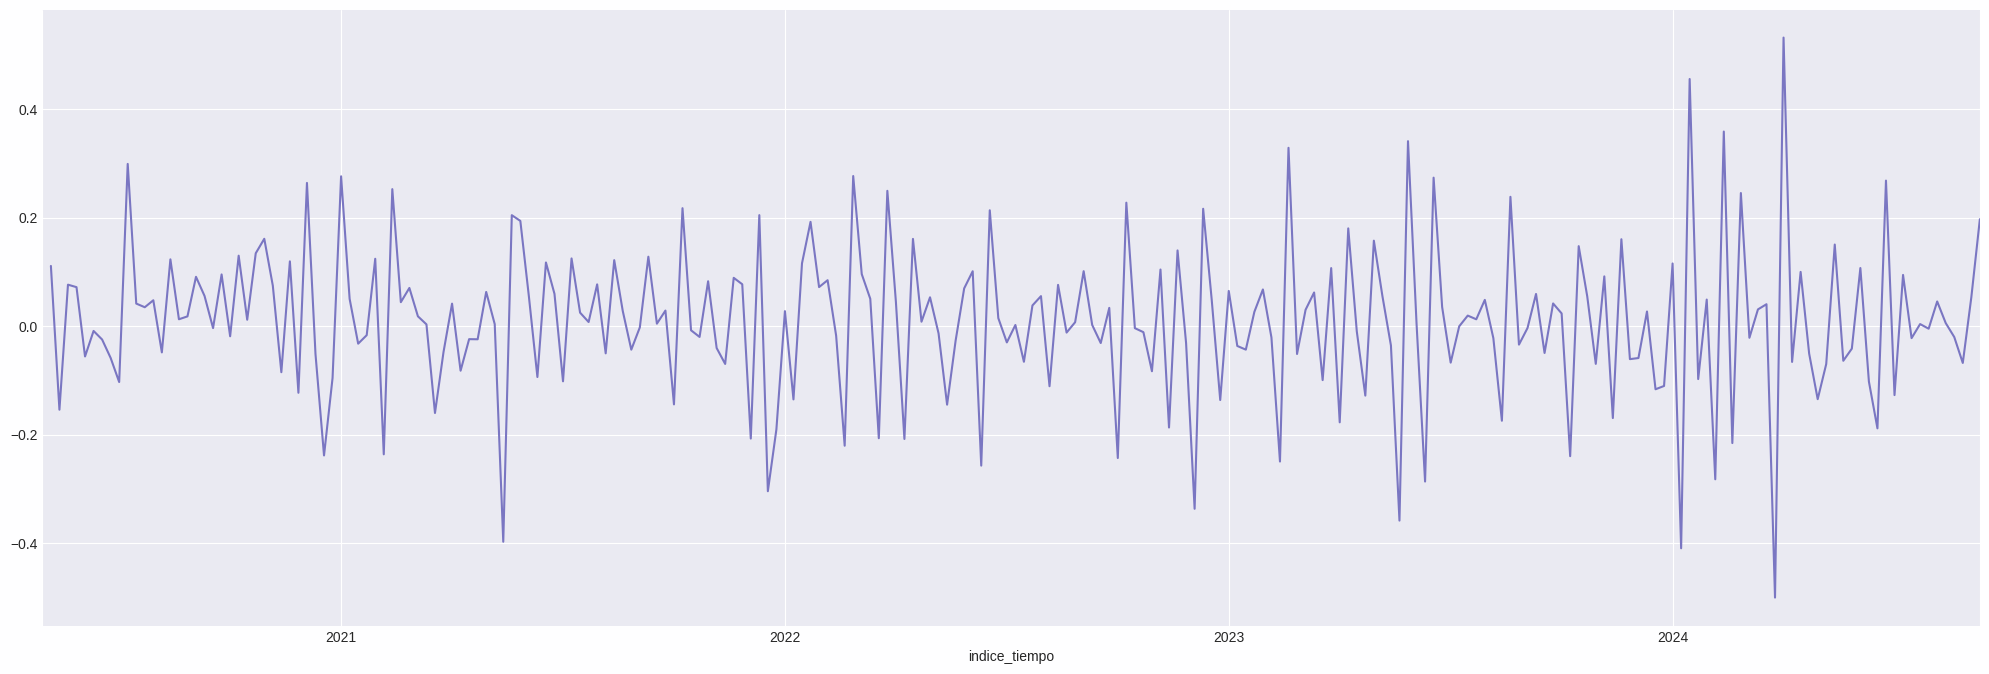

ADF Statistic: -16.543328
p-value: 0.000000
Critical Values:
	1%: -3.460
	5%: -2.874
	10%: -2.574


In [ ]:
df['tren_'] = df['tren'].apply(np.log).diff()
df.tren_.plot()
plt.show()
result = sdt_adf(df.tren_[1:])

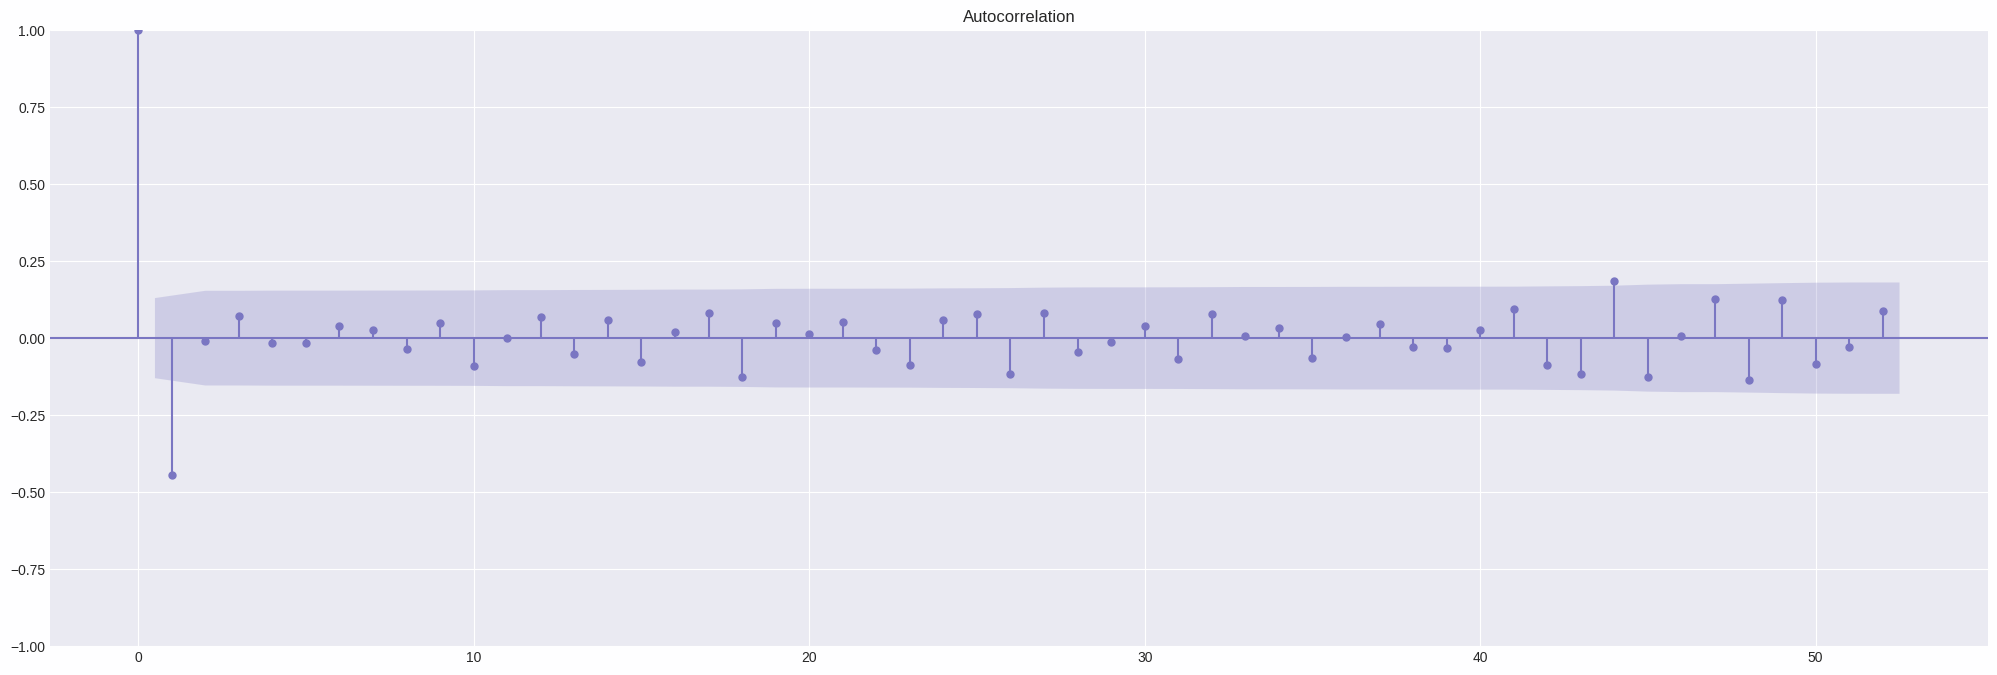

In [ ]:
plot_acf(df['tren_'][1:], lags = 52)
plt.show()

In [ ]:
def tsplot(y, lags=None, title='', figsize=(14, 7)):
    '''Examine the patterns of ACF and PACF, along with the time series plot and histogram.

    Original source: https://tomaugspurger.github.io/modern-7-timeseries.html
    '''
    fig = plt.figure(figsize=figsize)
    layout = (2, 2)
    ts_ax   = plt.subplot2grid(layout, (0, 0))
    hist_ax = plt.subplot2grid(layout, (0, 1))
    acf_ax  = plt.subplot2grid(layout, (1, 0))
    pacf_ax = plt.subplot2grid(layout, (1, 1))

    y.plot(ax=ts_ax)
    ts_ax.set_title(title)
    y.plot(ax=hist_ax, kind='hist', bins=25)
    hist_ax.set_title('Histogram')
    smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
    smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
    [ax.set_xlim(0) for ax in [acf_ax, pacf_ax]]
    sns.despine()
    plt.tight_layout()
    return ts_ax, acf_ax, pacf_ax

(<Axes: xlabel='indice_tiempo'>,
 <Axes: title={'center': 'Autocorrelation'}>,
 <Axes: title={'center': 'Partial Autocorrelation'}>)

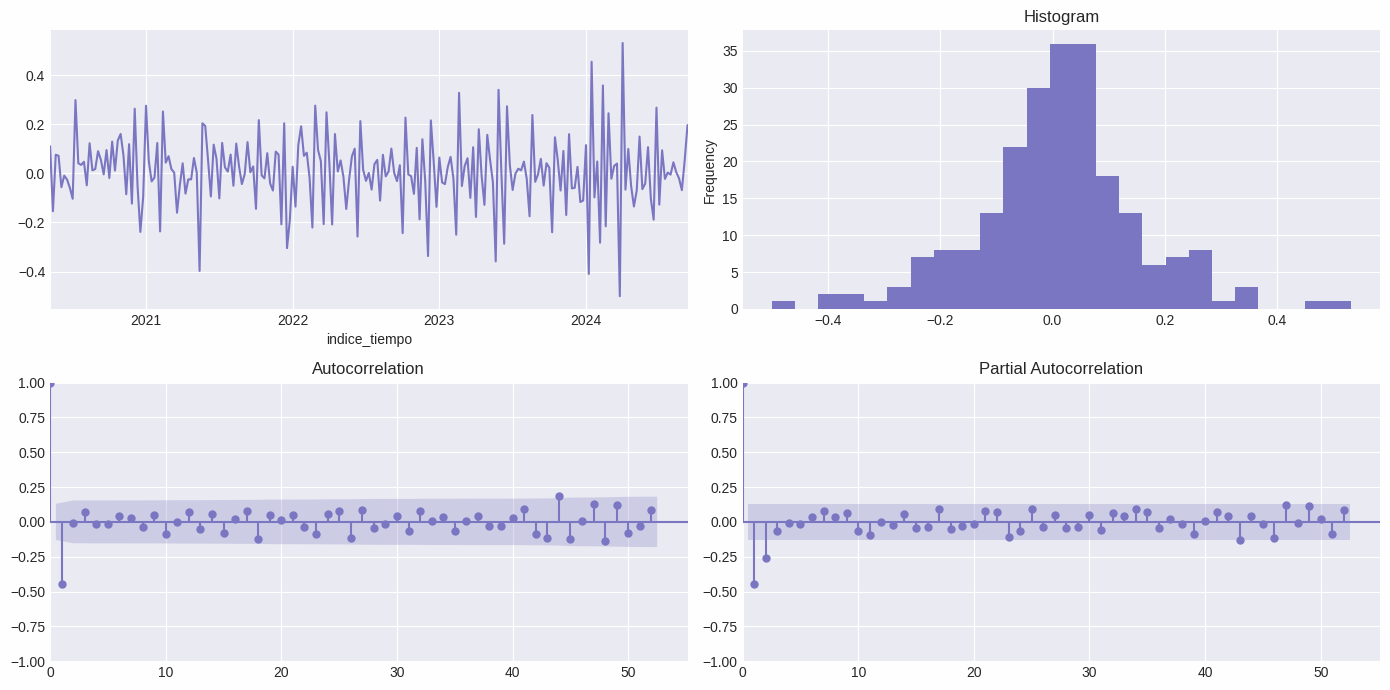

In [ ]:
tsplot(df["tren_"][1:],lags=52)

https://www.statsmodels.org/dev/generated/statsmodels.tsa.arima_process.ArmaProcess.html

In [ ]:
# creamos un generador de modelos arima y los exploramos:
1. observamos su comportamiento conjunto y

In [ ]:
# import statsmodels.api as sm
# import numpy as np
# np.random.seed(42)
# arparams = np.array([.75, -.25])
# maparams = np.array([.65, .35])
# ar = np.r_[1, -arparams] # add zero-lag and negate
# ma = np.r_[1, maparams] # add zero-lag
# arma_process = sm.tsa.ArmaProcess(ar, ma)
# arma_process.isstationary

# arma_process.isinvertible

# arma_process.arroots
# # np.array([1.5-1.32287566j, 1.5+1.32287566j])
# y = arma_process.generate_sample(250)
# model = sm.tsa.ARIMA(y, (2, 0, 2), trend='n').fit(disp=0)
# model.params
# # array([ 0.79044189, -0.23140636,  0.70072904,  0.40608028])

### White Noise

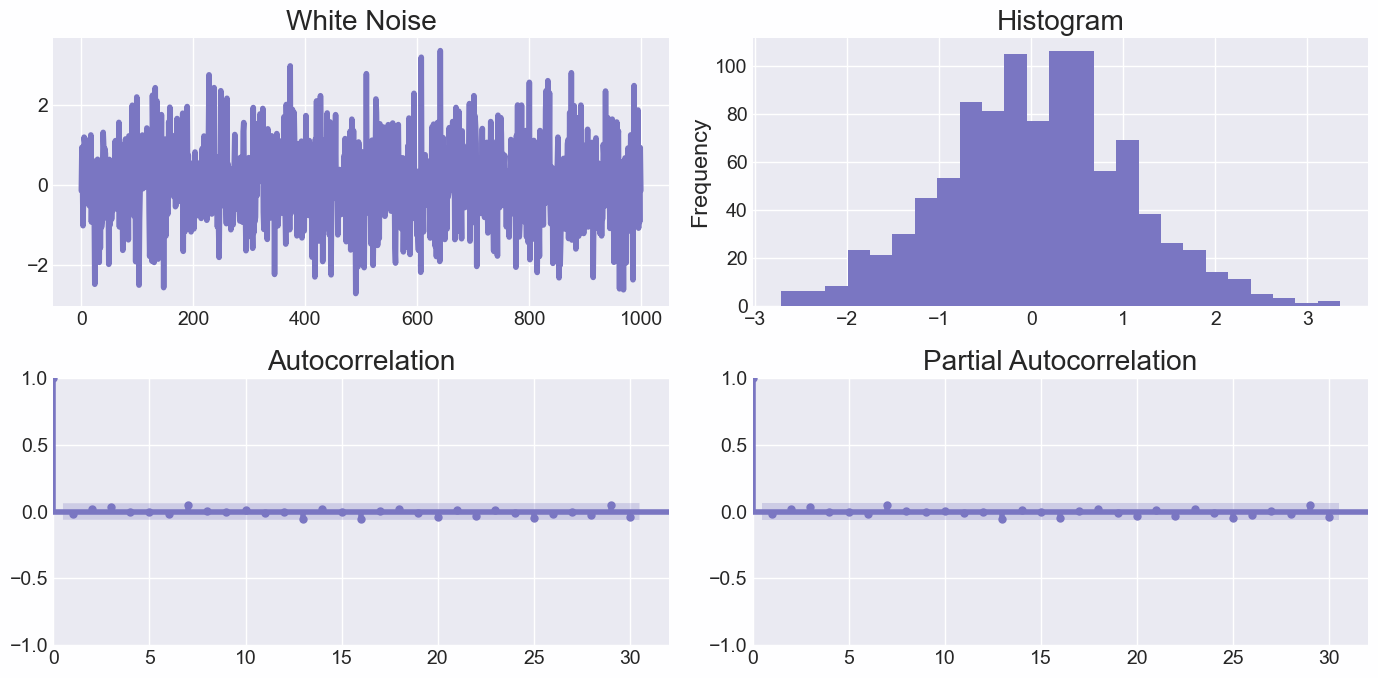

In [ ]:
_ = sdt_sim(title='White Noise')

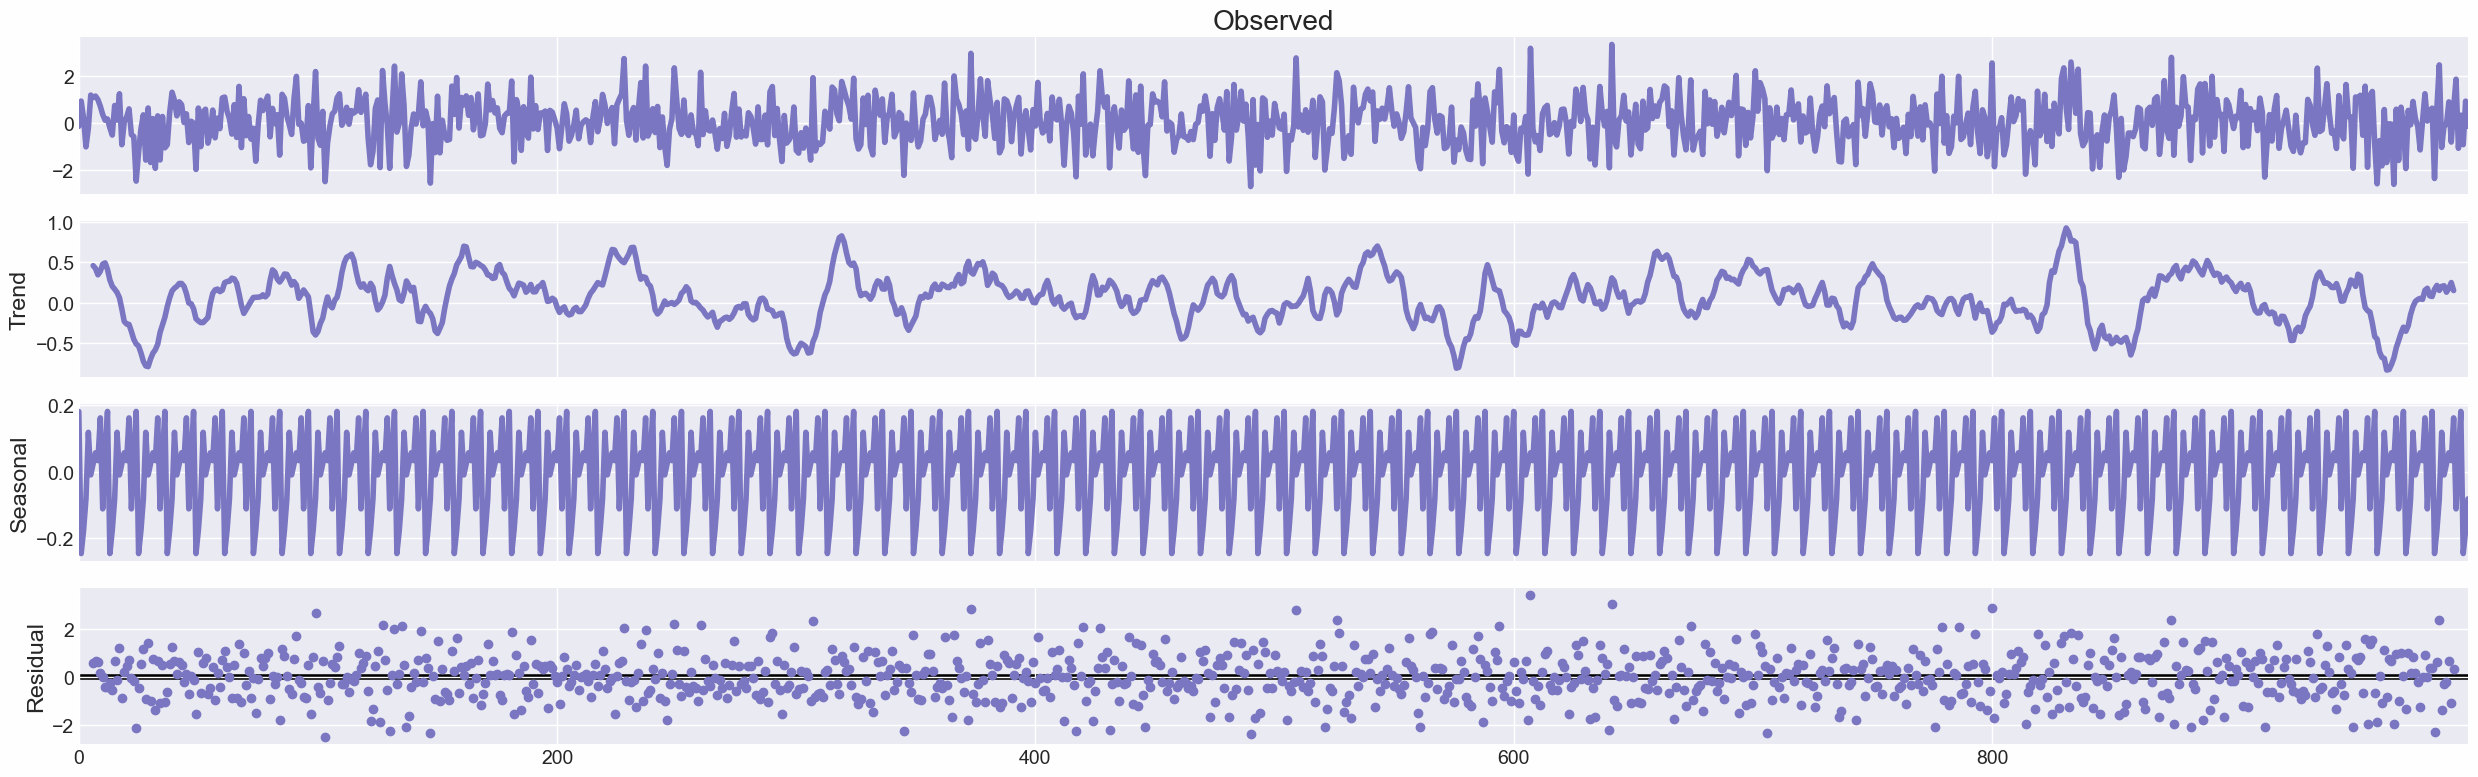

In [ ]:
# Descomposición de Ruido Blanco.... qué significa esto?
decomposition = sm.tsa.seasonal_decompose(_,period =12, model = 'additive')
figure = decomposition.plot()
plt.show()

### Random Walk

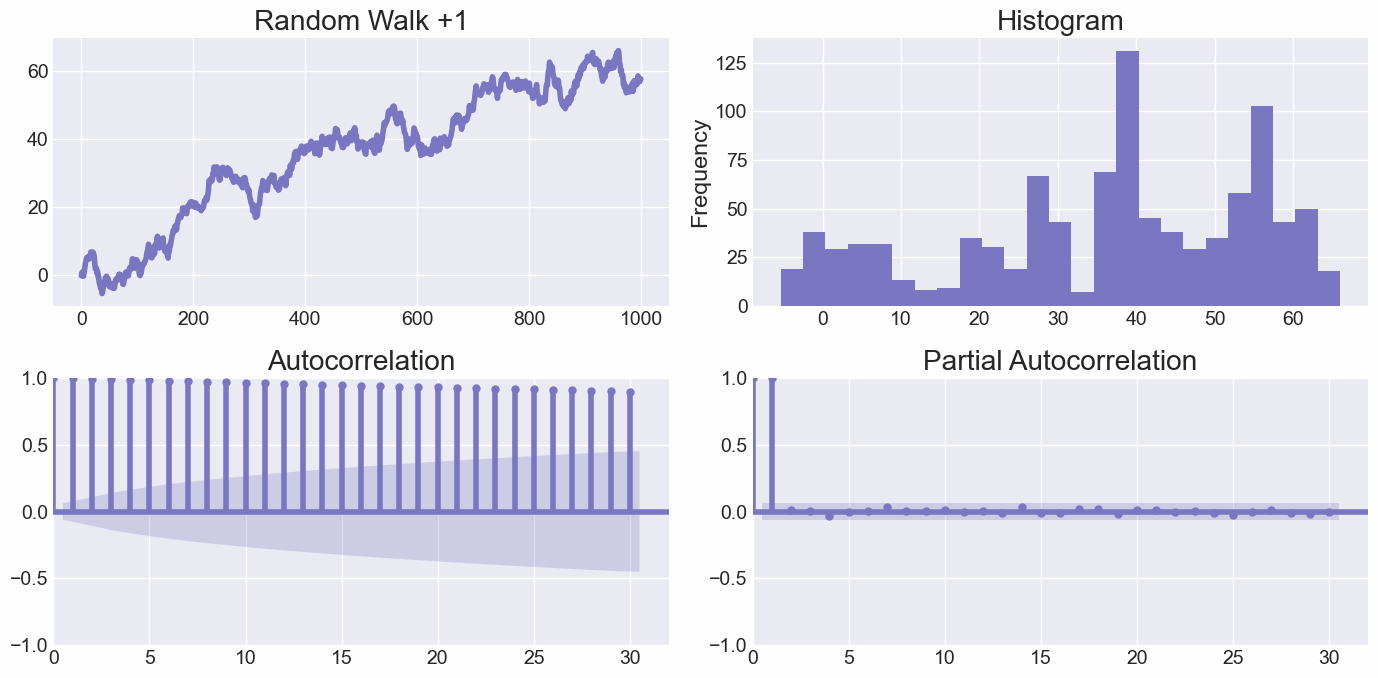

In [ ]:
_ = sdt_sim(AR=[1],title='Random Walk +1')

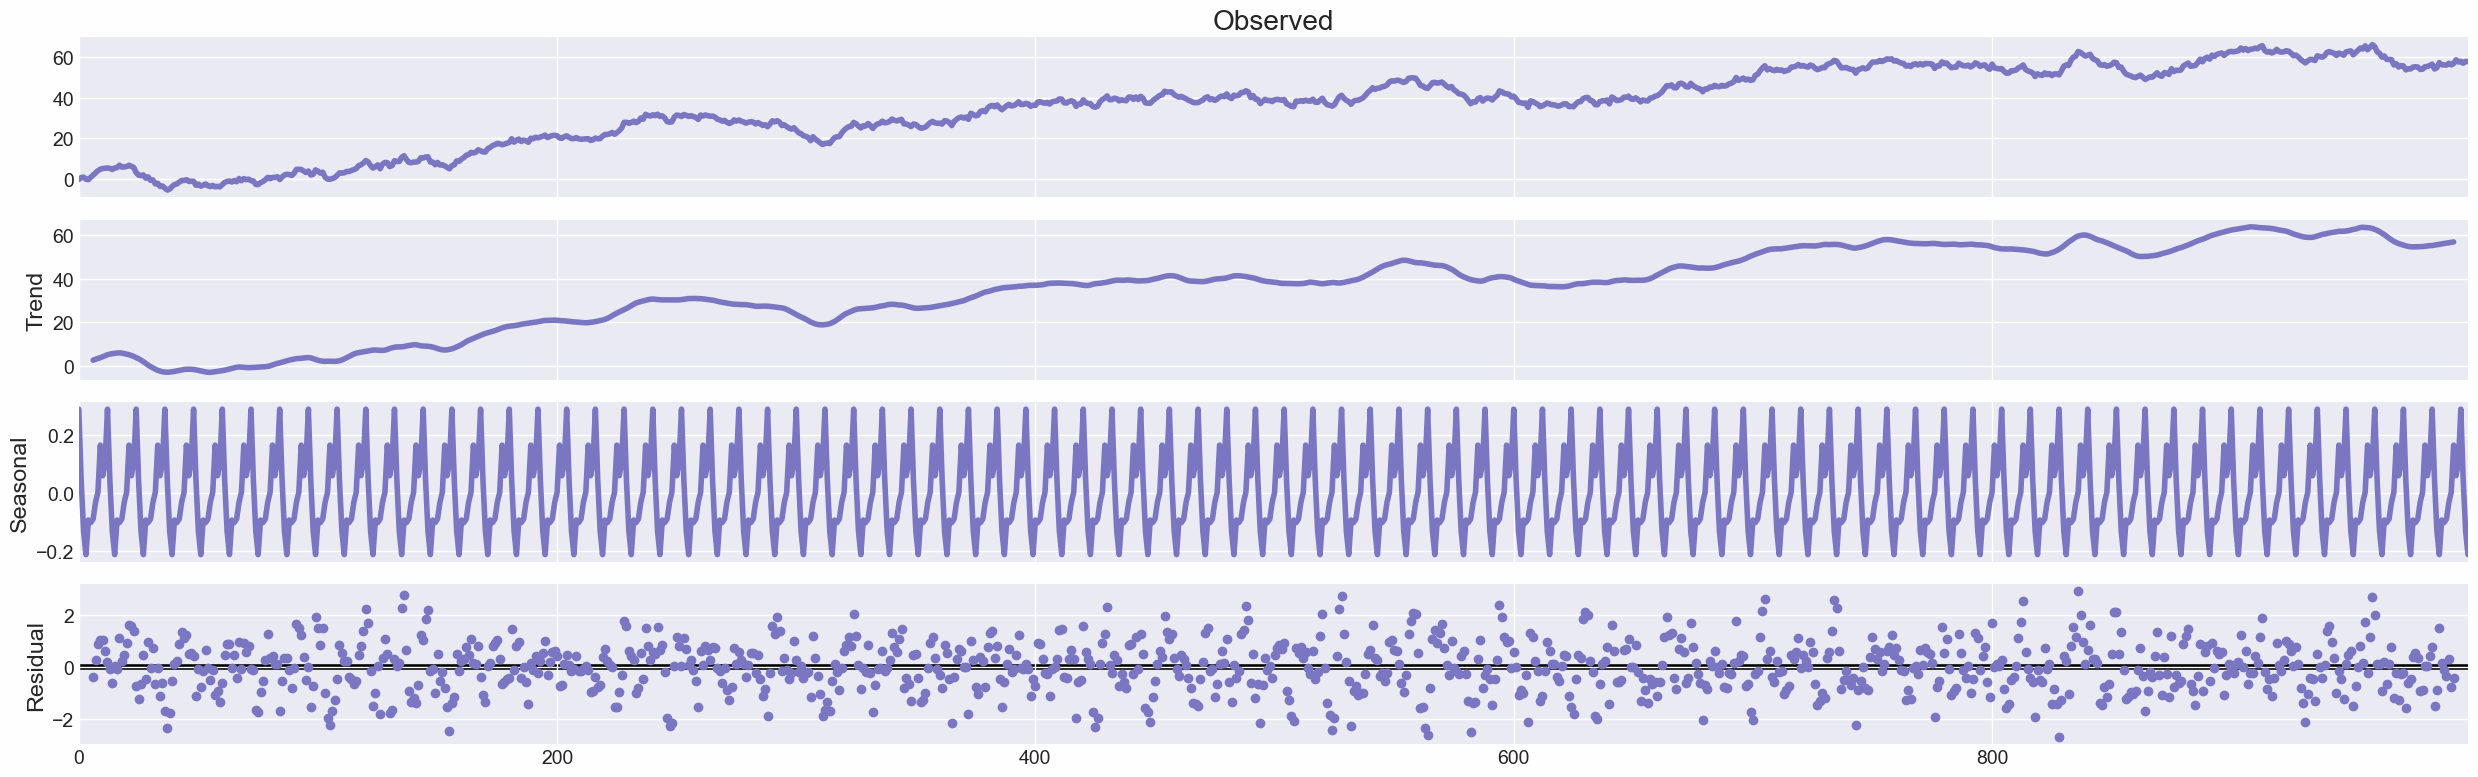

In [ ]:
# Descomposición de Random Walk.... qué significa esto?
decomposition = sm.tsa.seasonal_decompose(_,period =12, model = 'additive')
figure = decomposition.plot()
plt.show()

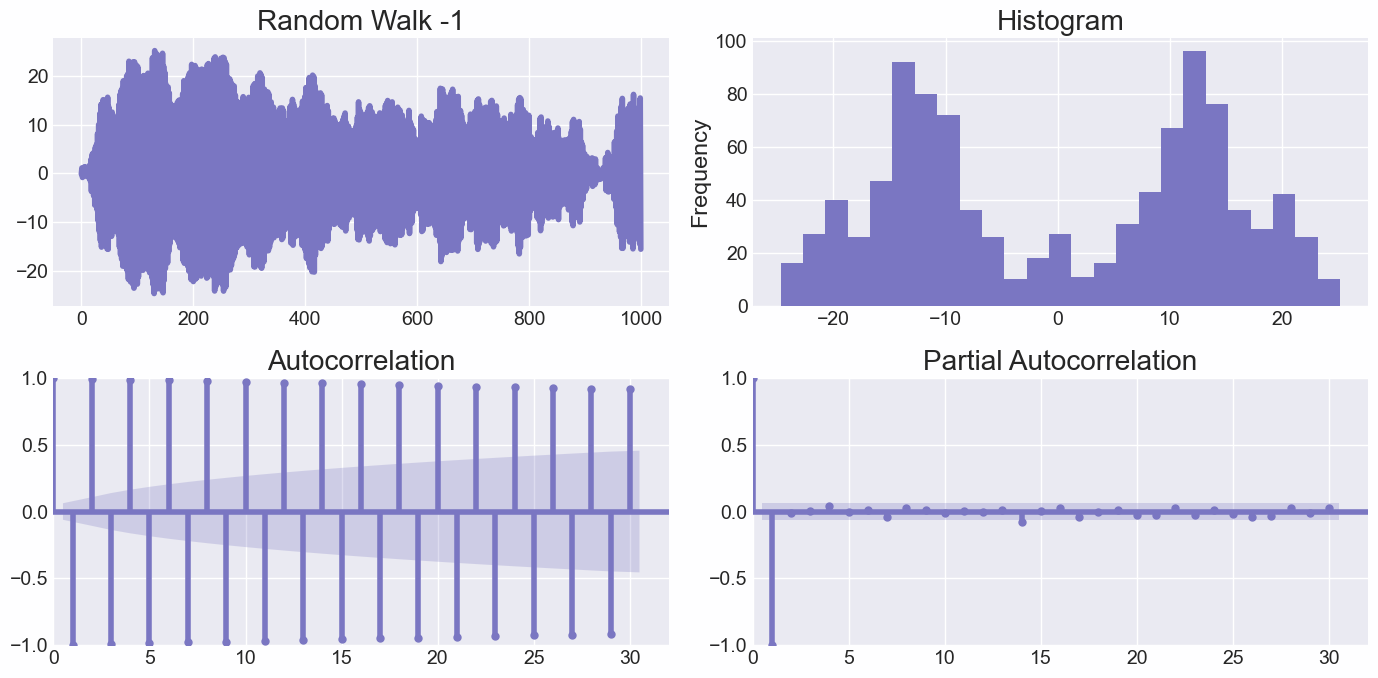

In [ ]:
_ = sdt_sim(AR=[-1],title='Random Walk -1')

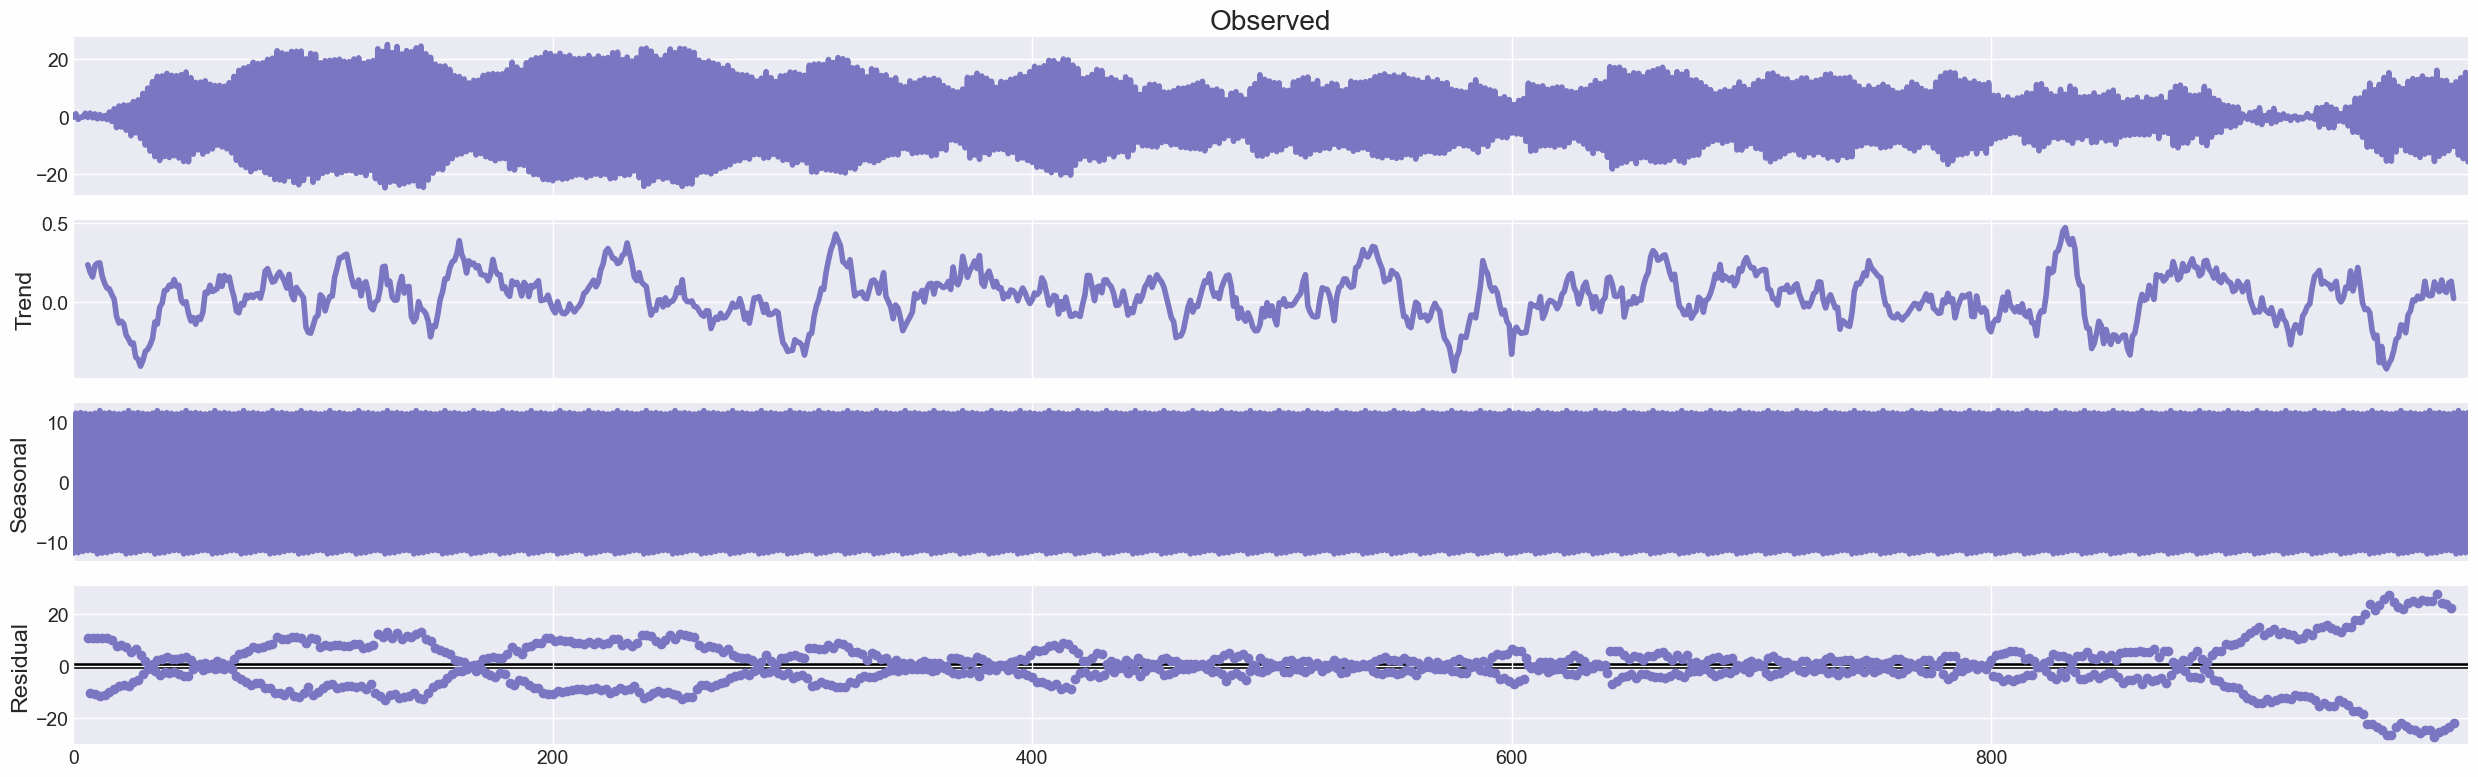

In [ ]:
# Descomposición de Random Walk.... qué significa esto?
decomposition = sm.tsa.seasonal_decompose(_,period =12, model = 'additive')
figure = decomposition.plot()
plt.show()

### AR(p)

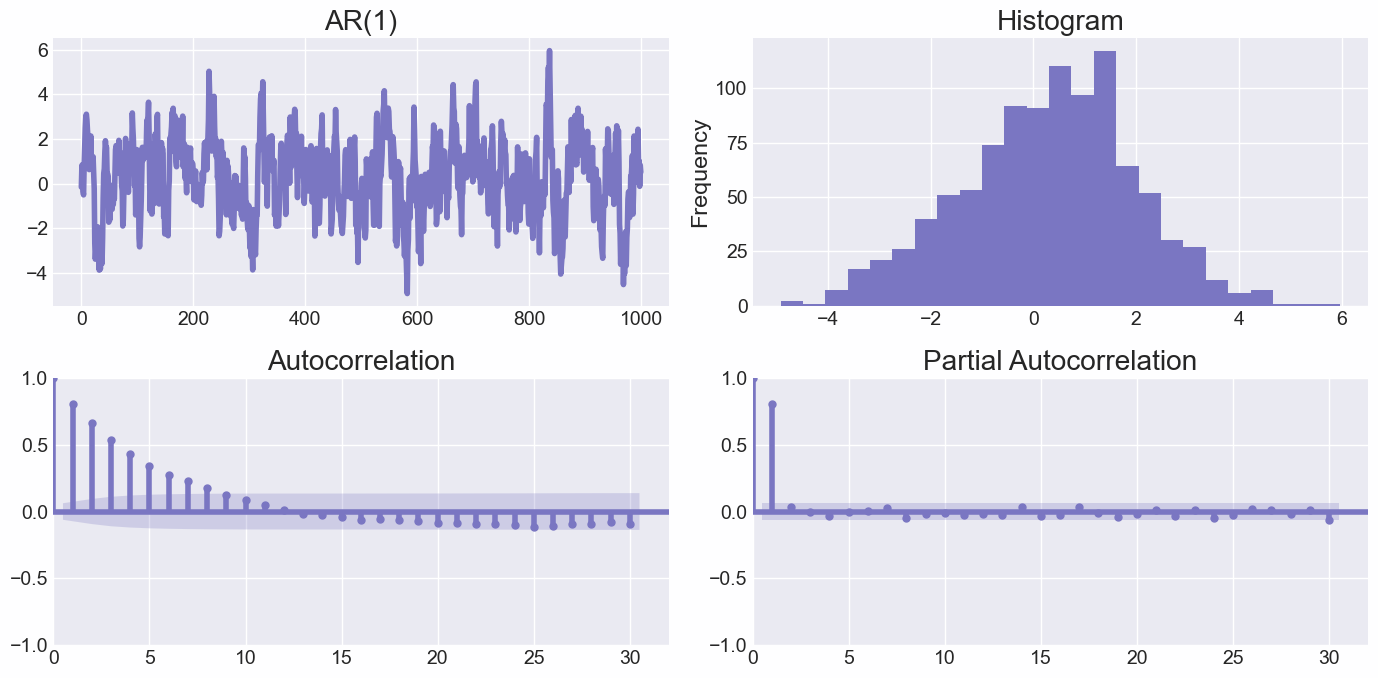

In [ ]:
# AR(1)
_ = sdt_sim(AR = [.8],title='AR(1)')

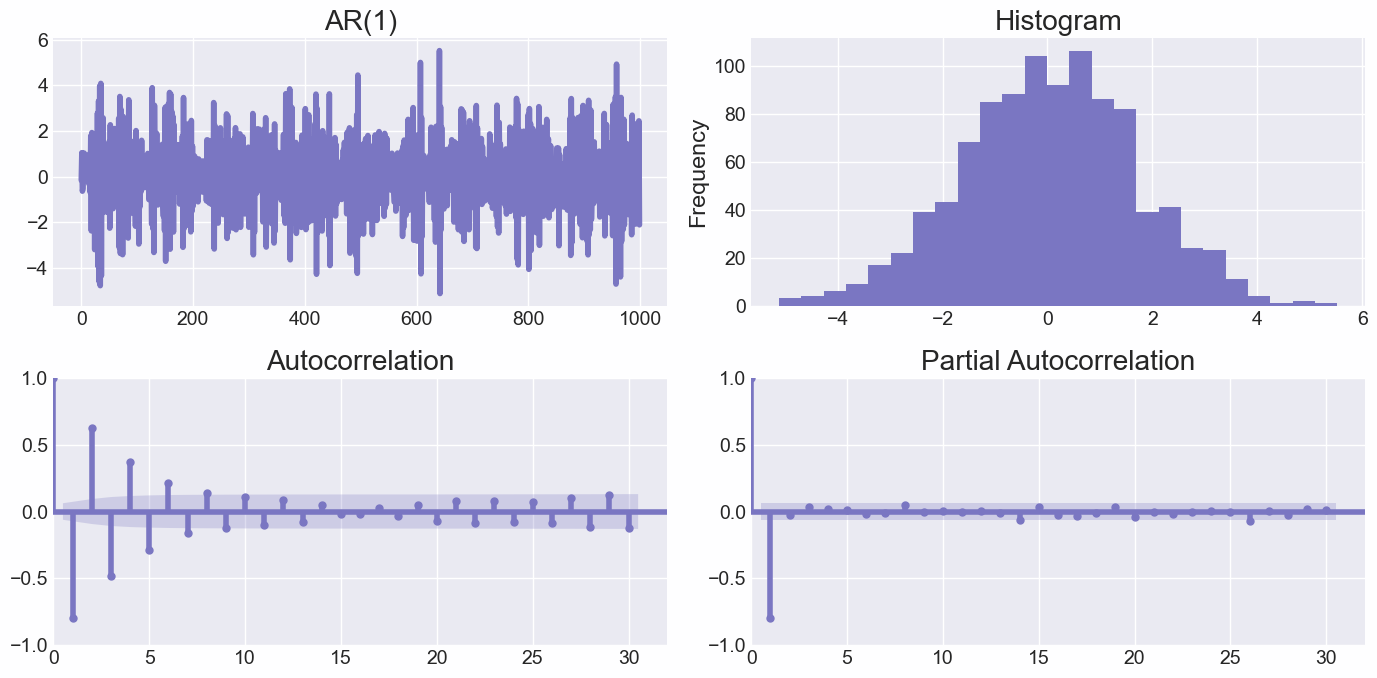

In [ ]:
# AR(1)
_ = sdt_sim(AR = [-.8],title='AR(1)')

In [ ]:
len(_)

1000

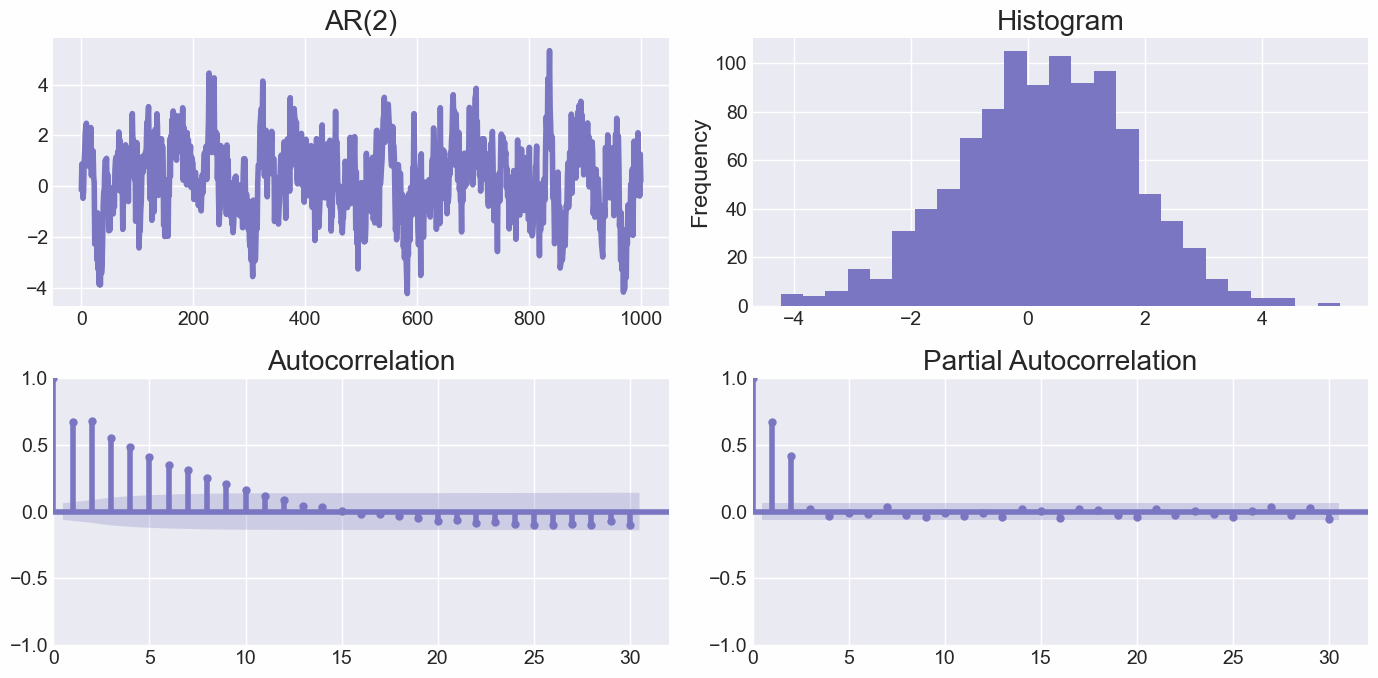

In [ ]:
# AR(2)
_ = sdt_sim(AR = [.4,0.4],title='AR(2)')

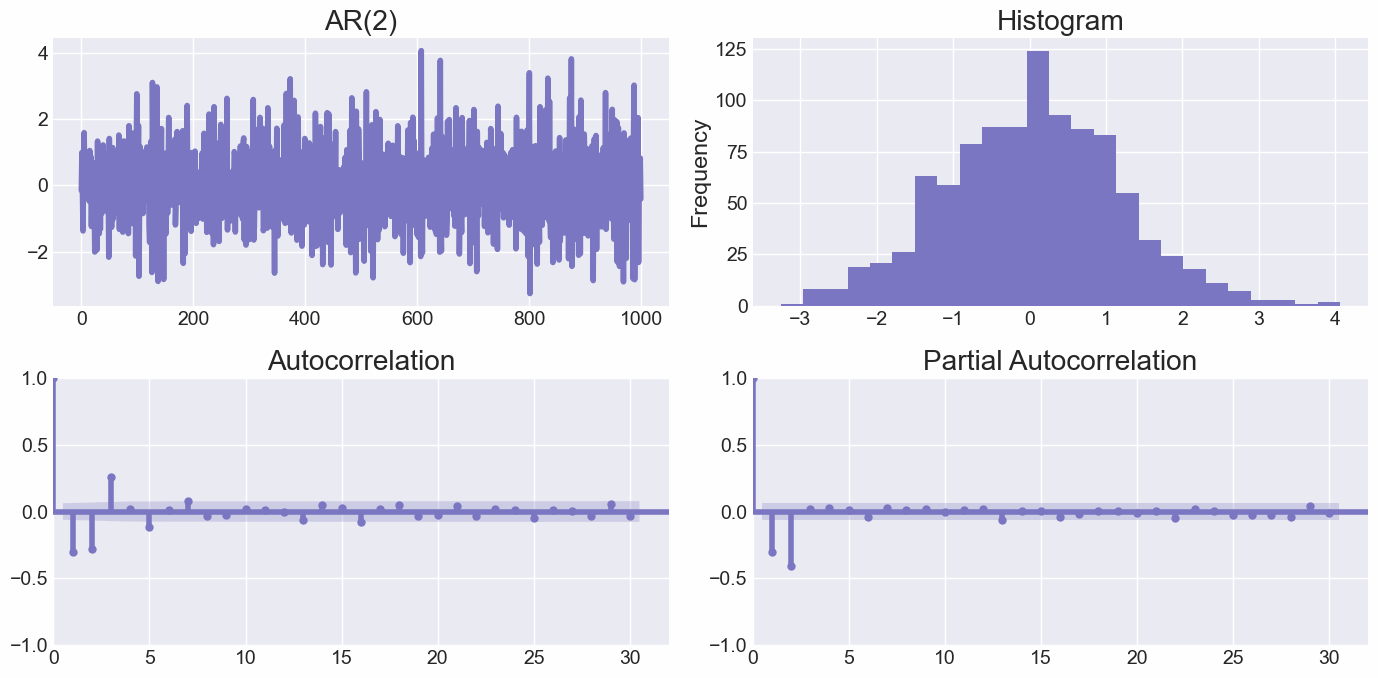

In [ ]:
# AR(2)
_ = sdt_sim(AR = [-.4,-0.4],title='AR(2)')

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


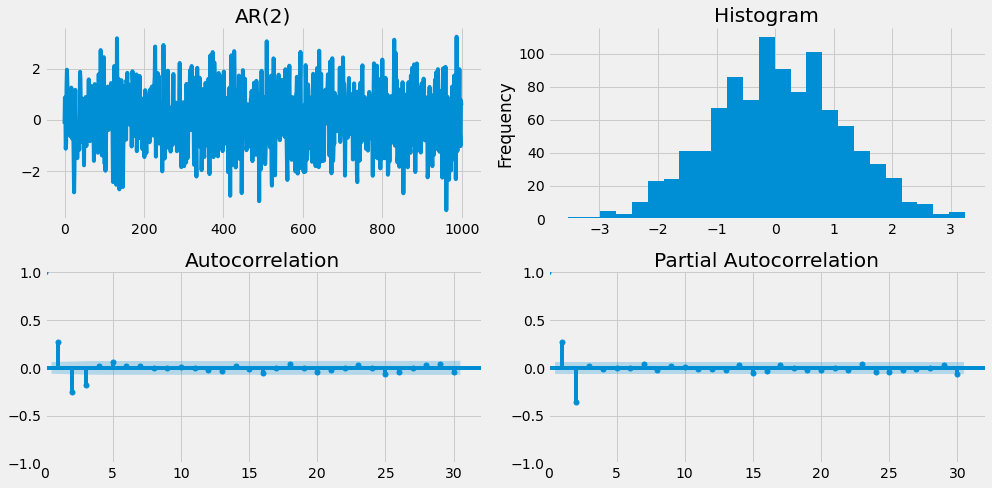

In [ ]:
# AR(2)
_ = sdt_sim(AR = [.4,-0.4],title='AR(2)')

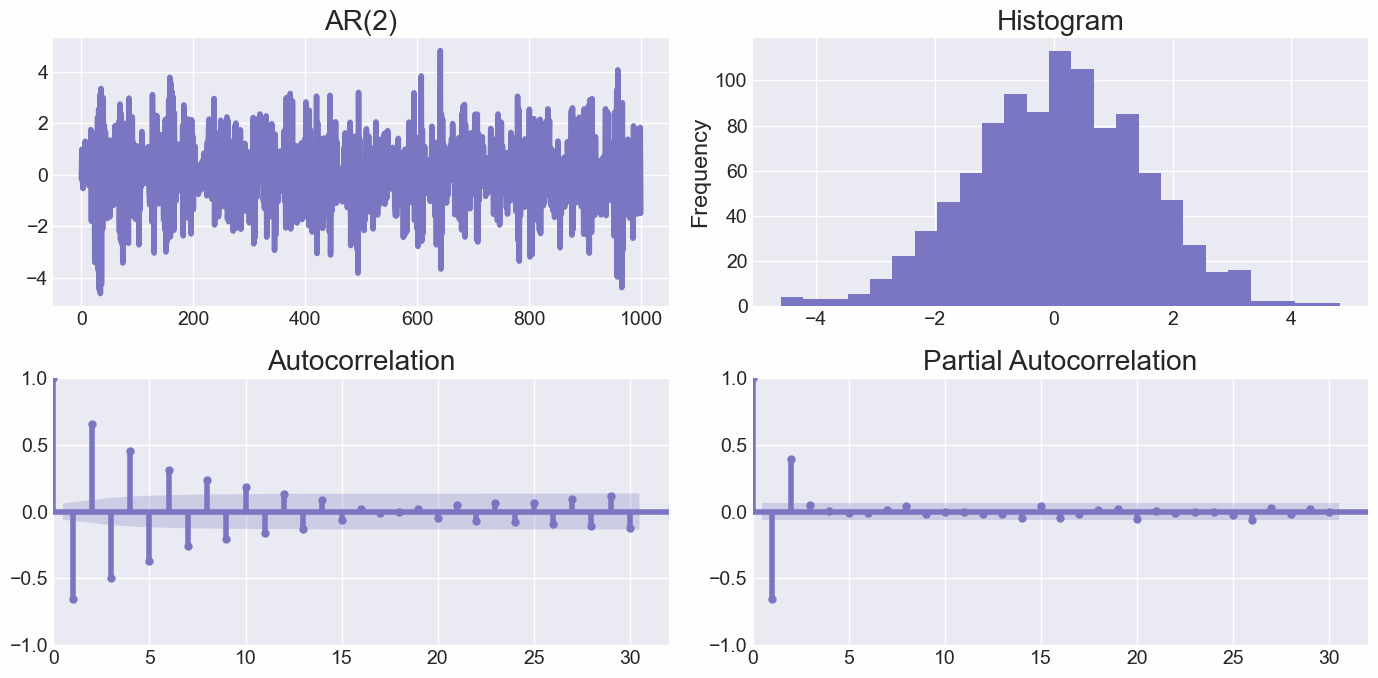

In [ ]:
# AR(2)
_ = sdt_sim(AR = [-.4,.4],title='AR(2)')

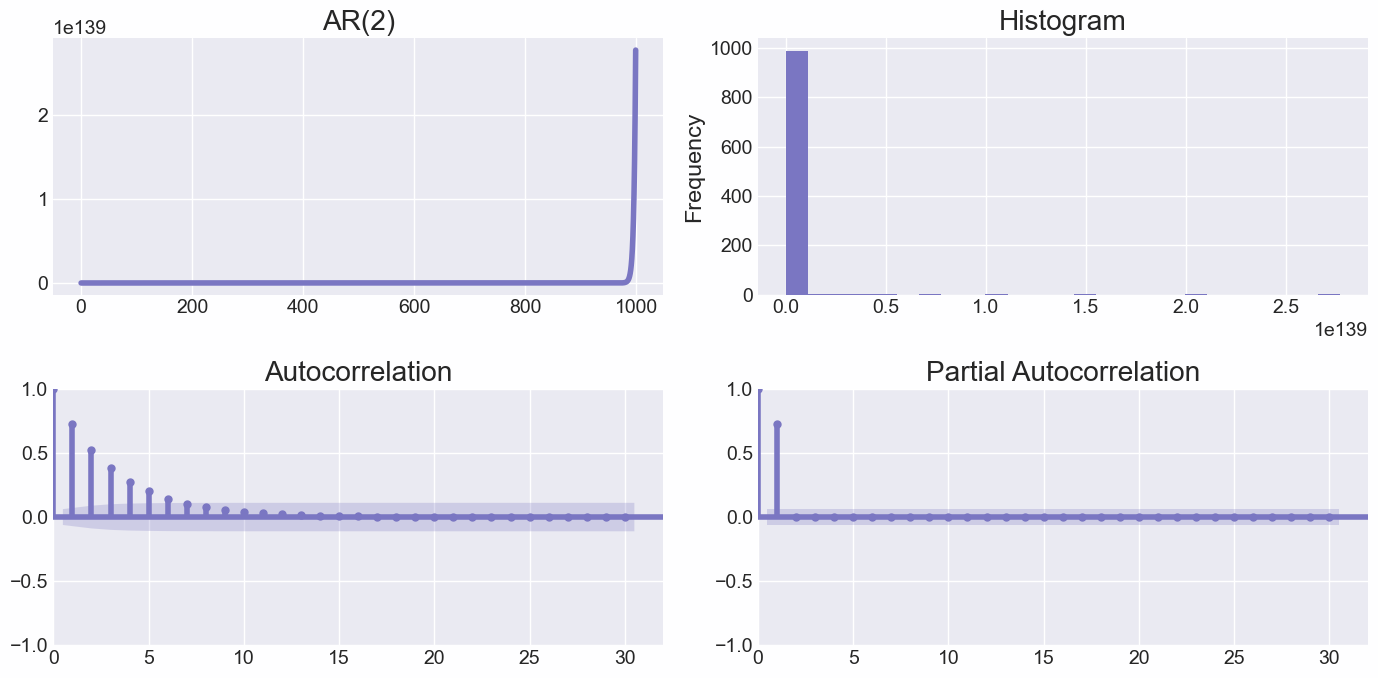

In [ ]:
# CASOS EXPLOSIVOS
# AR(2): vemos que la serie no es estacionaria (la suma de los coeficiente > 1)
_ = sdt_sim(AR = [.8,0.8],title='AR(2)')

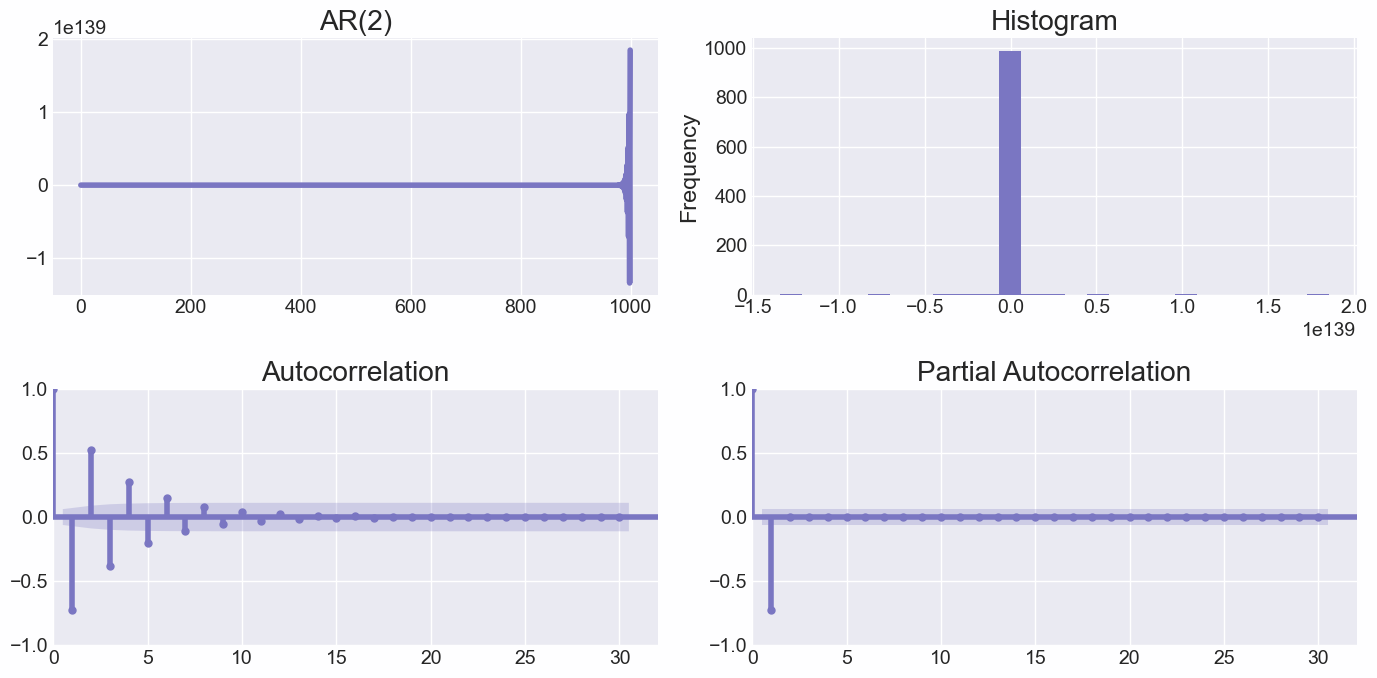

In [ ]:
# AR(2): vemos que la serie no es estacionaria (la suma en módulo de los coeficiente > 1 .
# Como antes, la explosividad negativa se da en el segundo momento (la varianza), mientras que en el caso positivo lo explosivo es la media.
_ = sdt_sim(AR = [-.8,0.8],title='AR(2)')

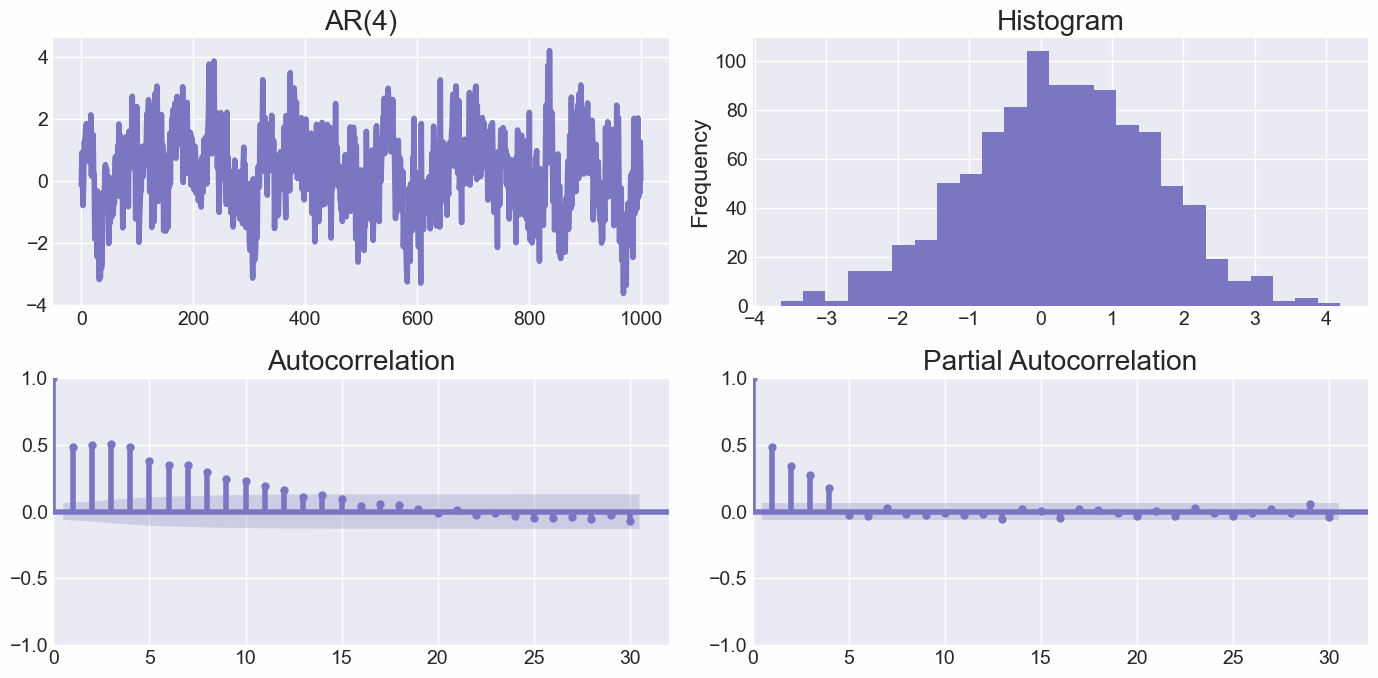

In [ ]:
# AR(4)
_ = sdt_sim(AR = [.2,0.2,0.2,0.2],title='AR(4)')

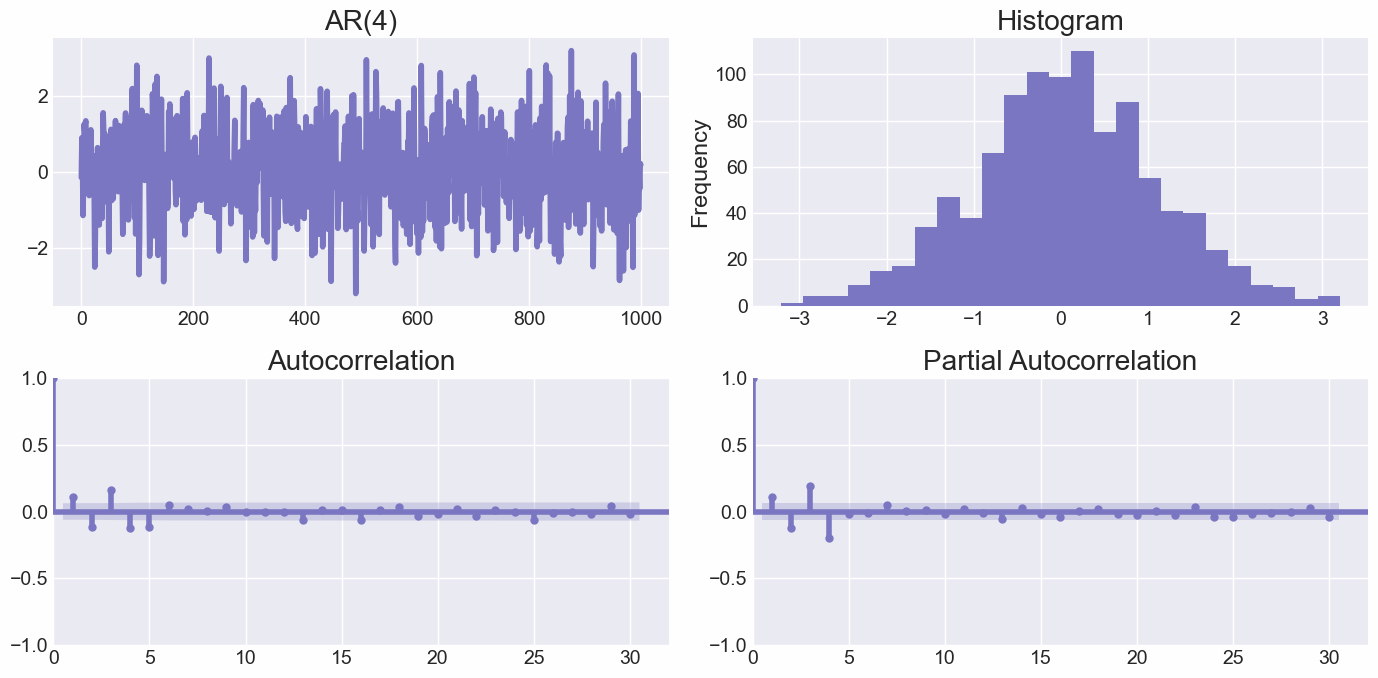

In [ ]:
# AR(4)
_ = sdt_sim(AR = [.2,-.2,.2,-.2],title='AR(4)')

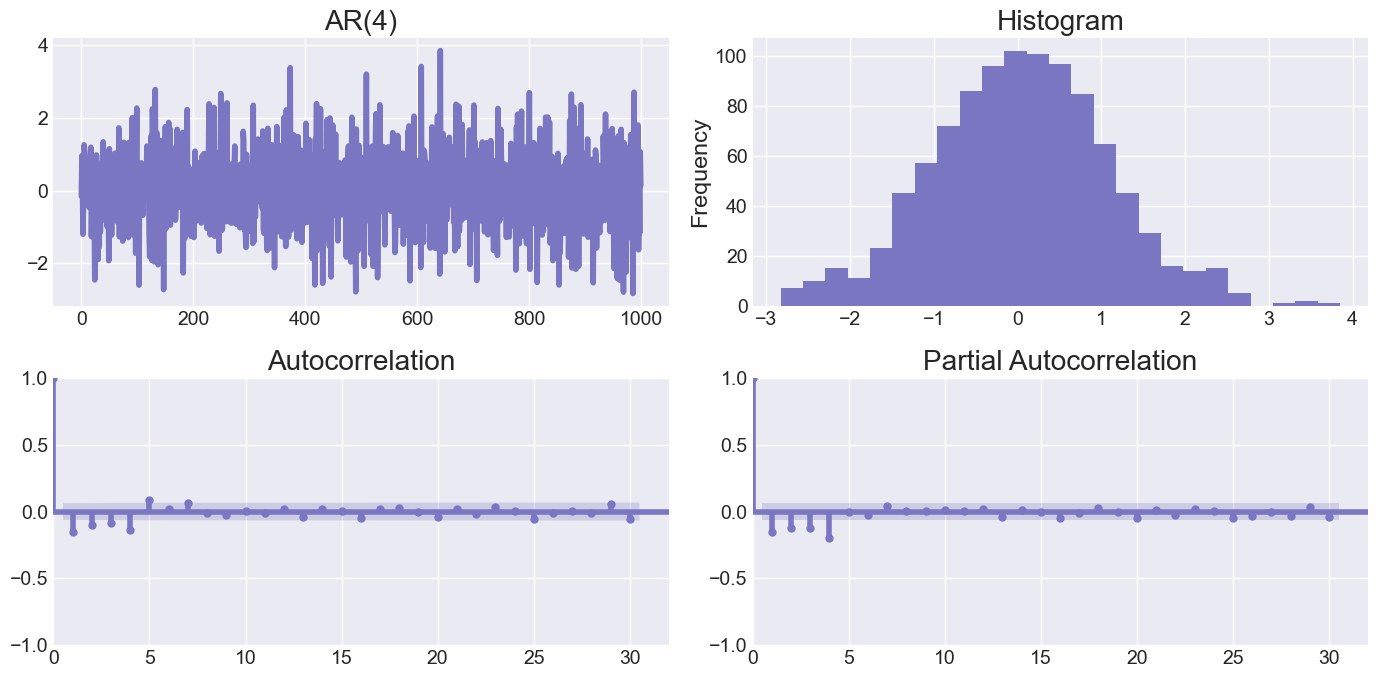

In [ ]:
# AR(4)
_ = sdt_sim(AR = [-.2,-.2,-.2,-.2],title='AR(4)')

### MA(q)

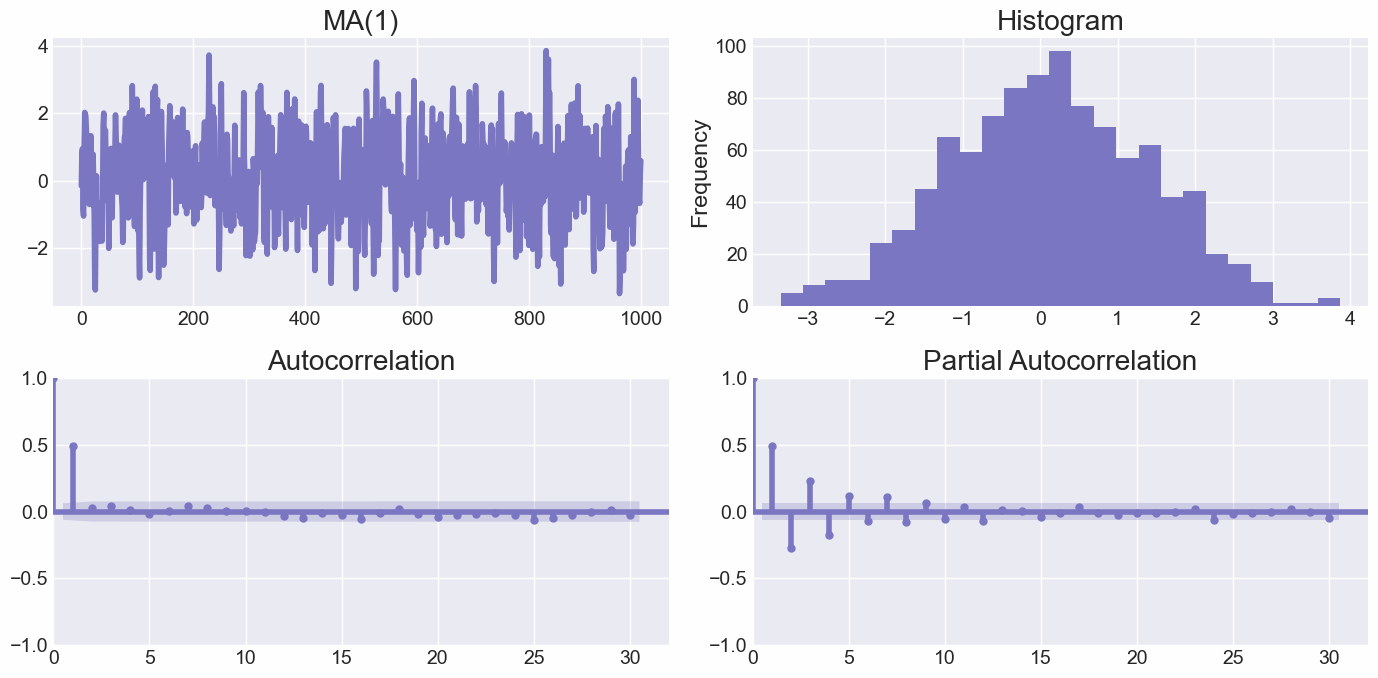

In [ ]:
# MA(1)
# Vemos que estamos en espejo con los procesos AR(p). La dinámica de los correlogramas es la misma que veríamos en un proceso AR(1) (con coeficiente negativo).
_ = sdt_sim(MA = [0.8],title='MA(1)')

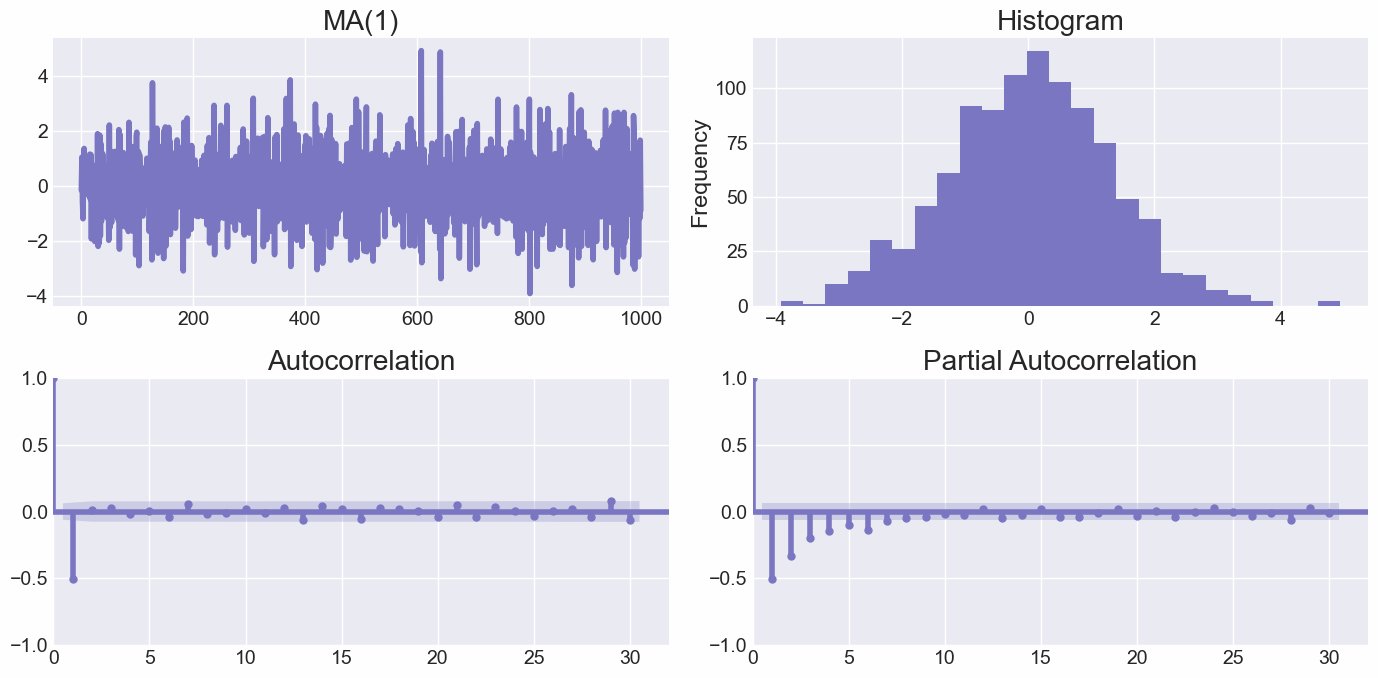

In [ ]:
# MA(1)
_ = sdt_sim(MA = [-0.8],title='MA(1)')

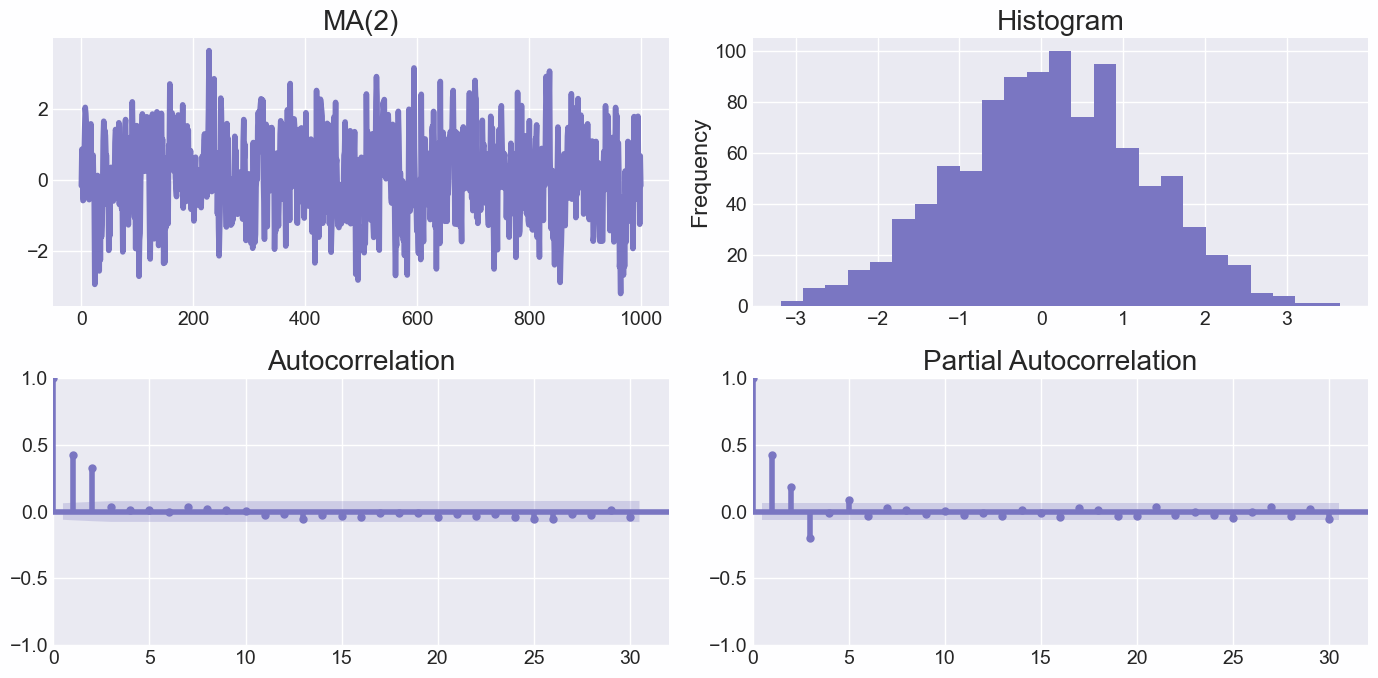

In [ ]:
# MA(2)
_ = sdt_sim(MA = [.4,.4],title='MA(2)')

In [ ]:
aa

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


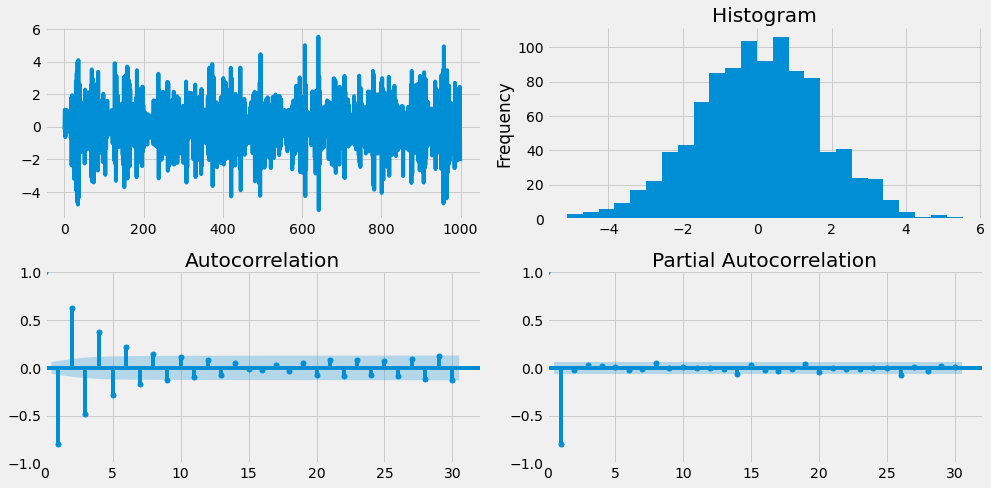

In [ ]:
# AR(1)
_ = sdt_sim(AR = [-.8])

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


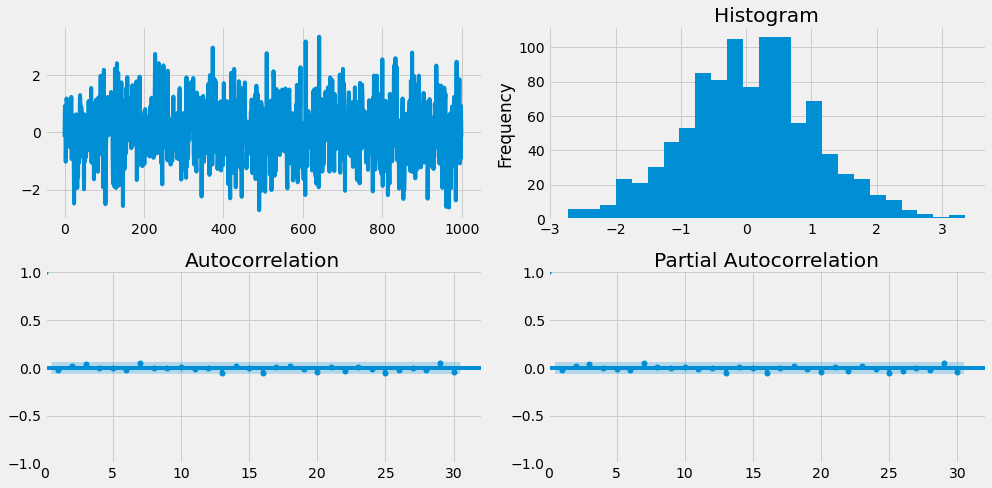

In [ ]:
# No todos los procesos son modelizables:
_ = sdt_sim(AR = [-.8,0.8],MA=[0.8,-0.8])

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


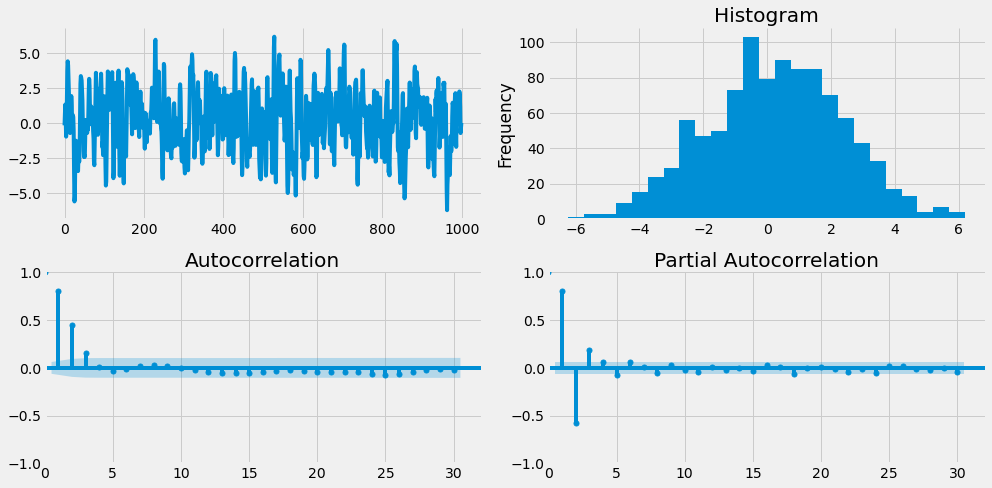

In [ ]:
# import statsmodels.api as sm
# import numpy as np
np.random.seed(113)
arparams = np.array([.75, -.25])
maparams = np.array([.65, .35])
ar = np.r_[1, -arparams] # add zero-lag and negate
ma = np.r_[1, maparams] # add zero-lag
arma_process = sm.tsa.ArmaProcess(ar, ma)
y = arma_process.generate_sample(1000)
tsplot(pd.Series(y));

In [ ]:
model = sm.tsa.ARIMA(endog=y, order=(2, 0, 2),trend='n')
res = model.fit()
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -1418.917
Date:                Wed, 19 Apr 2023   AIC                           2847.835
Time:                        10:16:10   BIC                           2872.374
Sample:                             0   HQIC                          2857.161
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7605      0.083      9.207      0.000       0.599       0.922
ar.L2         -0.2262      0.064     -3.507      0.000      -0.353      -0.100
ma.L1          0.6235      0.080      7.784      0.0

In [ ]:
arma_process.isstationary

True

In [ ]:
arma_process.isinvertible

True

In [ ]:
arma_process.arroots

array([1.5-1.32287566j, 1.5+1.32287566j])

In [ ]:
dates = pd.date_range("1980-1-1", freq="M", periods=1000)
y = pd.Series(y, index=dates)
arma_mod = sm.tsa.ARIMA(endog=y, order=(2, 0, 2),trend='n')
arma_res = arma_mod.fit()

In [ ]:
print(arma_res.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -1418.917
Date:                Wed, 19 Apr 2023   AIC                           2847.835
Time:                        10:23:31   BIC                           2872.374
Sample:                    01-31-1980   HQIC                          2857.161
                         - 04-30-2063                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7605      0.083      9.207      0.000       0.599       0.922
ar.L2         -0.2262      0.064     -3.507      0.000      -0.353      -0.100
ma.L1          0.6235      0.080      7.784      0.0

(<AxesSubplot:>,
 <AxesSubplot:title={'center':'Autocorrelation'}>,
 <AxesSubplot:title={'center':'Partial Autocorrelation'}>)

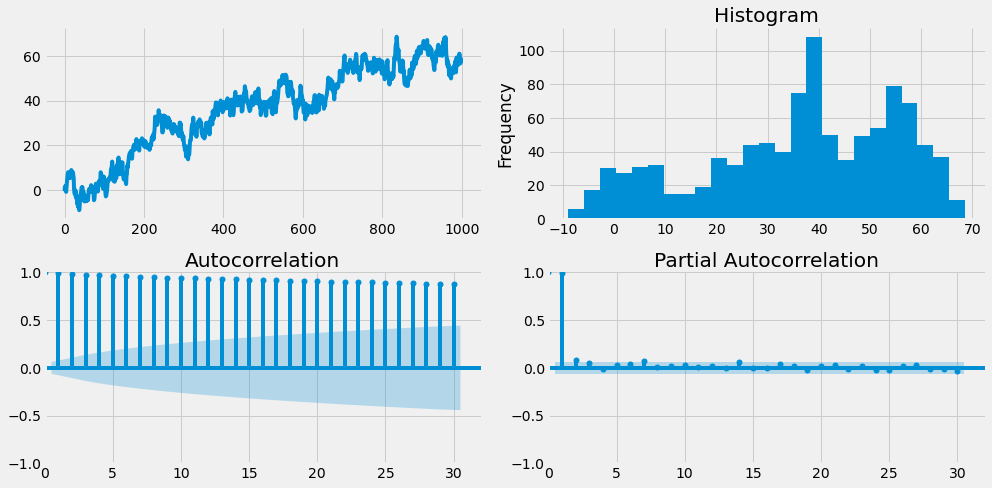

In [ ]:
tsplot(pd.Series(_))

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,
C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


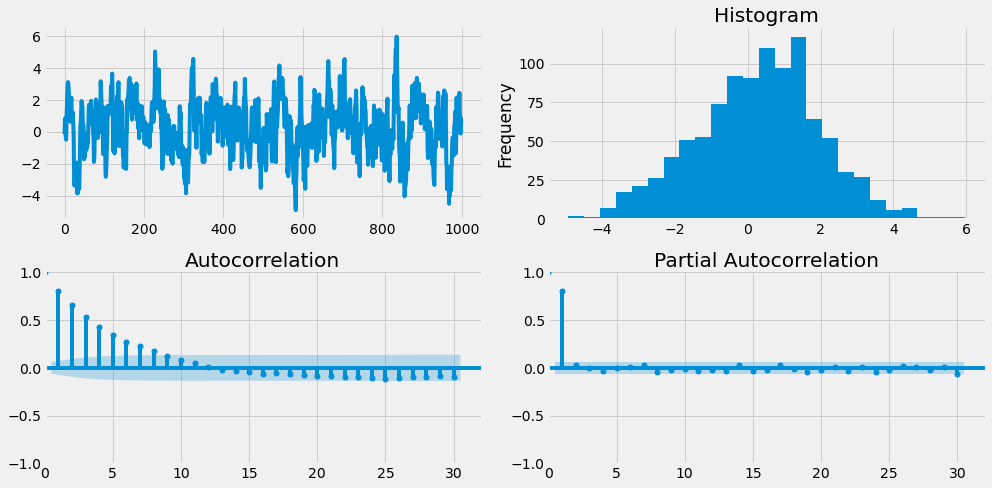

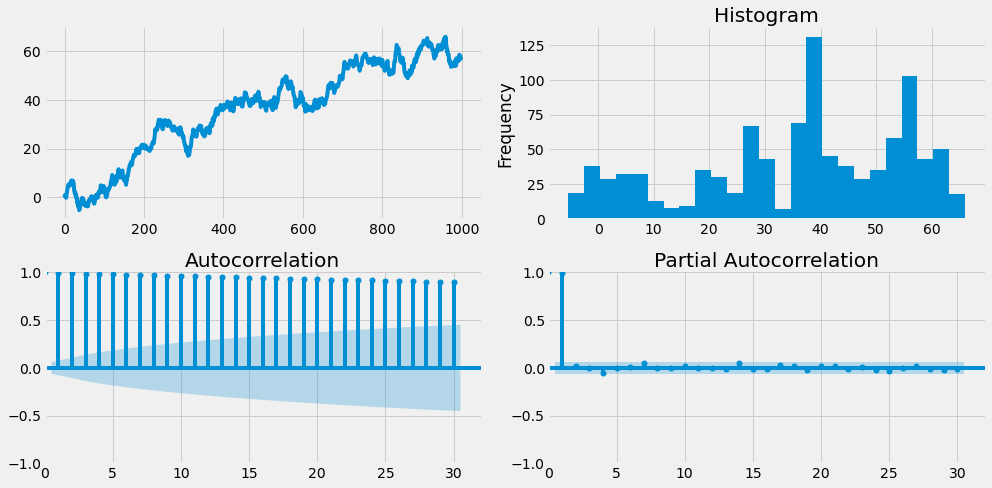

In [ ]:
_ = sdt_sim(AR = [.8]) + sdt_sim(AR = [1])

In [12]:
pip install tswidgets --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 53.6 MB/s eta 0:00:00
  Attempting uninstall: tswidgets
    Found existing installation: tswidgets 0.0.0
    Uninstalling tswidgets-0.0.0:
      Successfully uninstalled tswidgets-0.0.0


In [13]:
import tswidgets

In [14]:
from tswidgets import load_dataset

In [27]:
levendis = load_dataset('levendis')
hyndman = load_dataset('hyndman')
enders = load_dataset('enders')

<Axes: >

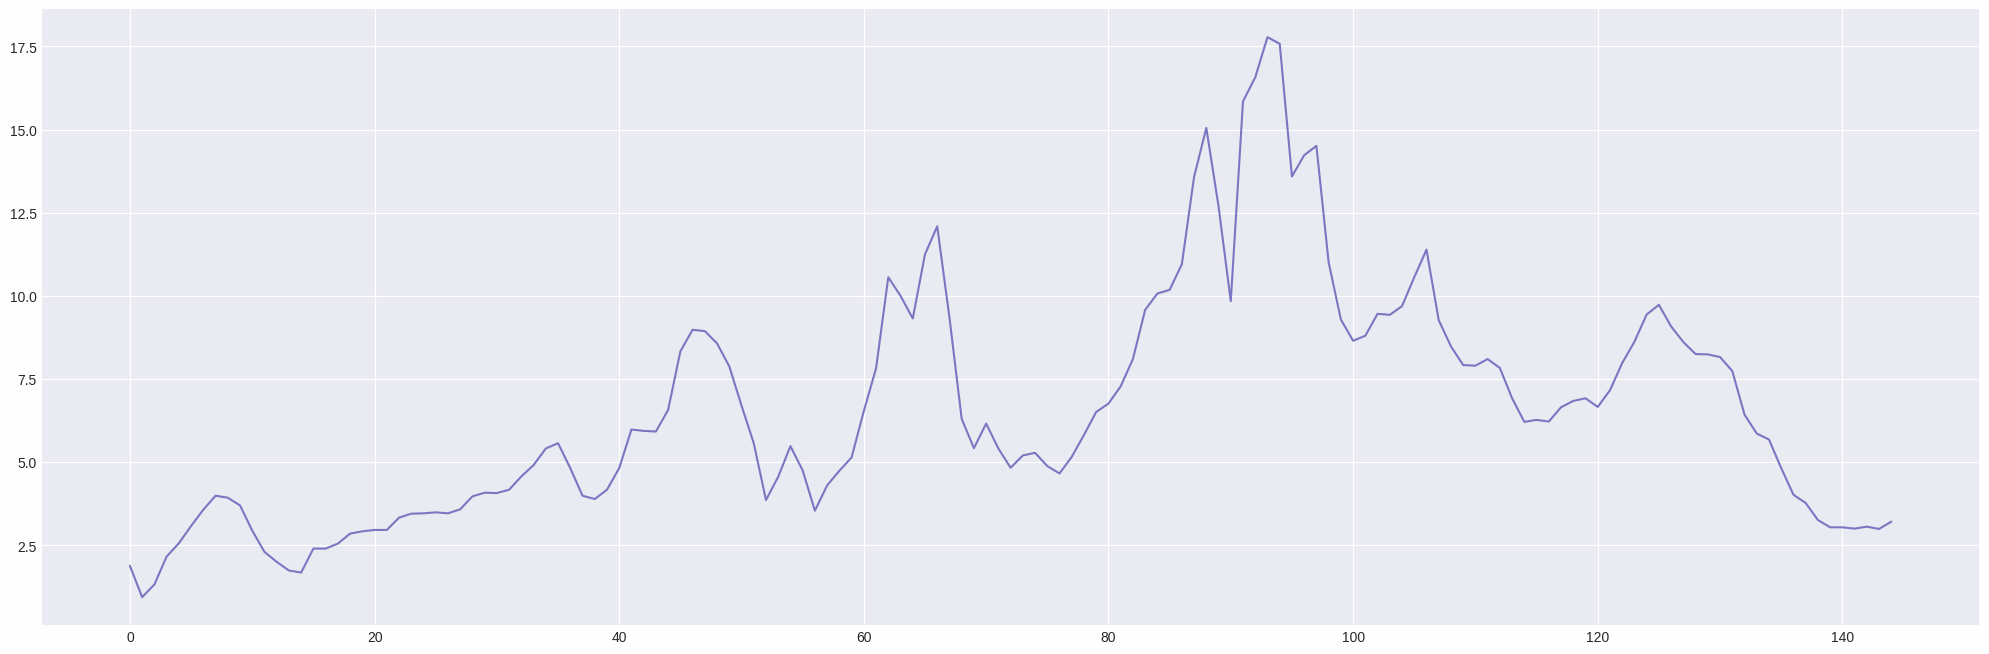

In [31]:
# enders.keys()
enders['granger'].r_short.plot()

<Axes: >

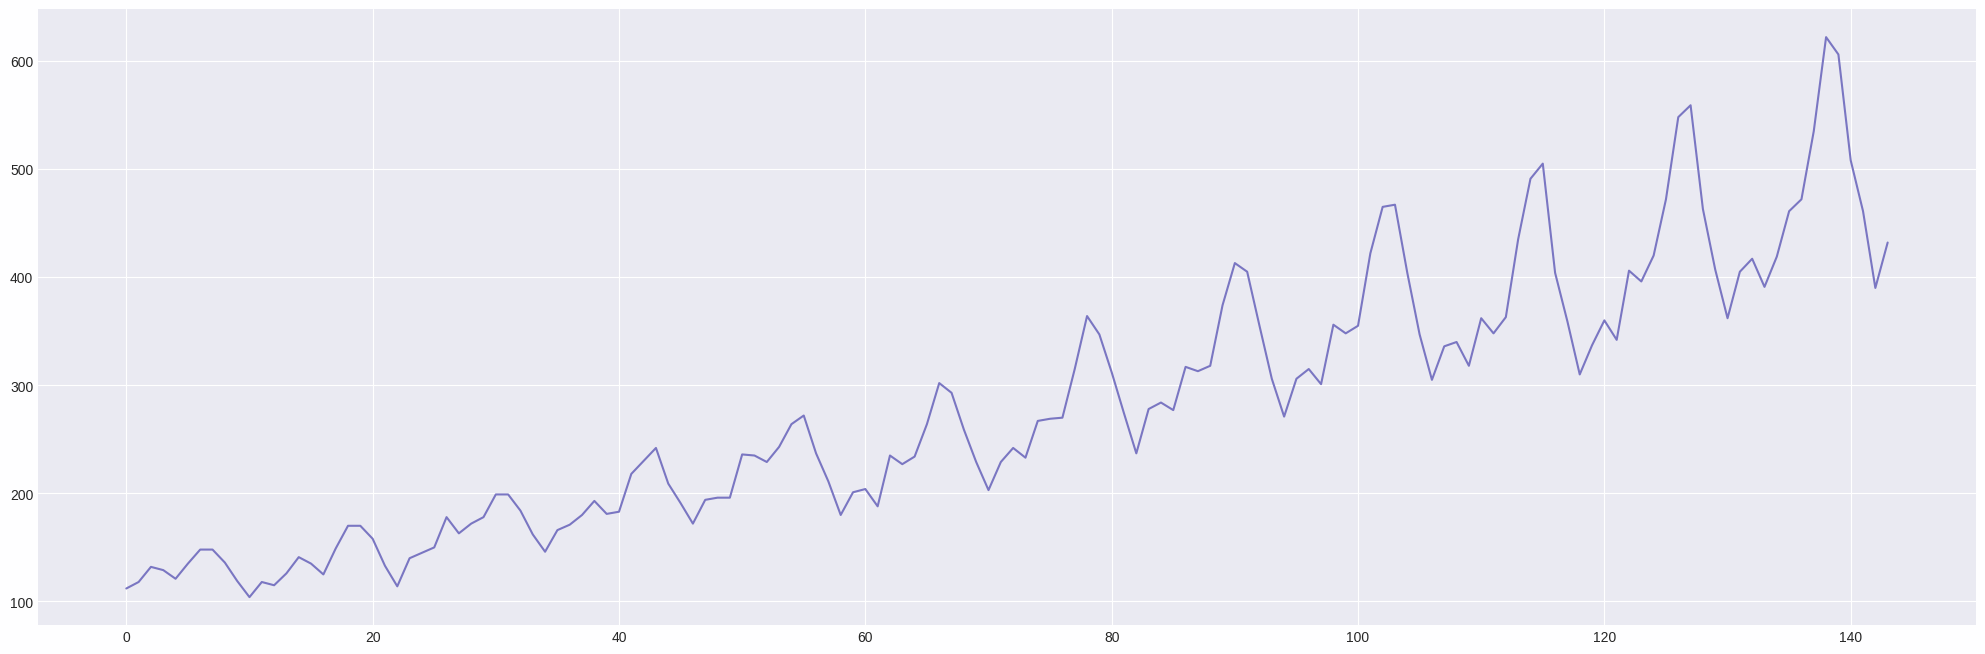

In [26]:
hyndman['rdatasets']['AirPassenger'].value.plot()

In [18]:
levendis['AR1nonzero_b']

,error,X
time,,
901,1.513708,20.861327
902,1.137759,21.568423
903,-0.153930,20.630281
904,-0.933758,19.381382
905,0.836555,20.527246
...,...,...
997,-0.794226,18.739033
998,-0.879115,18.490401
999,0.559183,19.804384


<!-- TODO:
* lag plots
* moar explanations? -->

<!-- <a id="section-five"></a>
# Causality

MOAR: Granger causality test is used to determine if one time series will be useful to forecast another. It is based on the idea that if X causes Y, then the forecast of Y based on previous values of Y AND the previous values of X should outperform the forecast of Y based on previous values of Y alone.
So, Granger causality test should not be used to test if a lag of Y causes Y. Instead, it is generally used on exogenous (not Y lag) variables only. It is implemented in the statsmodel package.
It accepts a 2D array with 2 columns as the main argument. The values are in the first column and the predictor (X) is in the second column. The Null hypothesis is that the series in the second column, does not Granger cause the series in the first. If the P-Values are less than a significance level (0.05) then we reject the null hypothesis and conclude that the said lag of X is indeed useful. The second argument maxlag says till how many lags of Y should be included in the test.a -->